In [1]:
# Import the necessary packages
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn.functional as F
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# Ensure reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

In [3]:
class VGG19_MLP(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        # Load pretrained VGG19
        #backbone = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        try:
            backbone = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        except AttributeError:
            backbone = models.vgg19(pretrained=True)
        # Use only the convolutional feature extractor part
        self.feature_extractor = backbone.features
        for param in self.feature_extractor.parameters():
            param.requires_grad = False  # freeze feature extractor

        # Adaptive pooling to make feature size independent of input size
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))  # same as original VGG output
        # Compute flattened feature size (512*7*7 = 25088)
        feature_dim = 512 * 7 * 7

        # Define 2-layer MLP classifier
        self.fc1 = nn.Linear(feature_dim, 224)
        self.fc2 = nn.Linear(224, num_classes)

    def forward(self, x):
        with torch.no_grad():  # feature extractor frozen
            x = self.feature_extractor(x)
            x = self.avgpool(x)
            x = torch.flatten(x, 1)

        self.hidden = F.relu(self.fc1(x))
        out = self.fc2(self.hidden)
        return out

In [4]:
model_artpainting = VGG19_MLP().to('cuda')
model_photos = VGG19_MLP().to('cuda')
model_mixup_01 = VGG19_MLP().to('cuda')
model_mixup_03 = VGG19_MLP().to('cuda')
model_mixup_05 = VGG19_MLP().to('cuda')
model_mixup_07 = VGG19_MLP().to('cuda')
model_mixup_09 = VGG19_MLP().to('cuda')

In [5]:
model_artpainting.load_state_dict(torch.load("/home/aban/circuit_tracing/finetuned_weights/PACS/pacs_artpainting_vgg42.pth"))
model_photos.load_state_dict(torch.load("/home/aban/circuit_tracing/finetuned_weights/PACS/pacs_photo_vgg42.pth"))
model_mixup_01.load_state_dict(torch.load("../mixup_weights/pacs_mixup_0.1_42_vgg19.pth"))
model_mixup_03.load_state_dict(torch.load("../mixup_weights/pacs_mixup_0.3_42_vgg19.pth"))
model_mixup_05.load_state_dict(torch.load("../mixup_weights/pacs_mixup_0.5_42_vgg19.pth"))
model_mixup_07.load_state_dict(torch.load("../mixup_weights/pacs_mixup_0.7_42_vgg19.pth"))
model_mixup_09.load_state_dict(torch.load("../mixup_weights/pacs_mixup_0.9_42_vgg19.pth"))

/tmp/ipykernel_2962316/2121220579.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_artpainting.load_state_dict(torch.load("/home/aban/circuit_tracing/finetuned_weig

<All keys matched successfully>

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

# your transform
pacs_transforms = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor()
])

# load the dataset from one root directory with subfolders 0-9
pacs = datasets.ImageFolder(root="/home/aban/circuit_tracing/pacs/pacs_data/pacs_data/art_painting", transform=pacs_transforms)


# set generator with fixed seed
generator = torch.Generator().manual_seed(42)

# sizes for train/test split (e.g., 80/20)
train_size = int(0.8 * len(pacs))
test_size = len(pacs) - train_size

artpainting_train_dataset, artpainting_test_dataset = random_split(pacs, [train_size, test_size], generator=generator)

print(f"Train size: {len(artpainting_train_dataset)}")
print(f"Test size: {len(artpainting_test_dataset)}")

#Load the artpainting dataset
artpainting_train_loader = DataLoader(artpainting_train_dataset, batch_size=512, shuffle=True, generator=generator)
artpainting_test_loader = DataLoader(artpainting_test_dataset, batch_size=512, shuffle=False)

Train size: 1638
Test size: 410


In [7]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

# your transform
pacs_transforms = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor()
])

# load the dataset from one root directory with subfolders 0-9
pacs = datasets.ImageFolder(root="/home/aban/circuit_tracing/pacs/pacs_data/pacs_data/photo", transform=pacs_transforms)


# set generator with fixed seed
generator = torch.Generator().manual_seed(42)

# sizes for train/test split (e.g., 80/20)
train_size = int(0.8 * len(pacs))
test_size = len(pacs) - train_size

photo_train_dataset, photo_test_dataset = random_split(pacs, [train_size, test_size], generator=generator)

print(f"Train size: {len(photo_train_dataset)}")
print(f"Test size: {len(photo_test_dataset)}")

#Load the artpainting dataset
photo_train_loader = DataLoader(photo_train_dataset, batch_size=512, shuffle=True, generator=generator)
photo_test_loader = DataLoader(photo_test_dataset, batch_size=512, shuffle=False)

Train size: 1336
Test size: 334


In [8]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

# your transform
pacs_transforms = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor()
])

# load the dataset from one root directory with subfolders 0-9
pacs = datasets.ImageFolder(root="../pacs_mixup/pacs_mixup_art_photo_0.1", transform=pacs_transforms)


# set generator with fixed seed
generator = torch.Generator().manual_seed(42)

# sizes for train/test split (e.g., 80/20)
train_size = int(0.8 * len(pacs))
test_size = len(pacs) - train_size

mixup01_train_dataset, mixup01_test_dataset = random_split(pacs, [train_size, test_size], generator=generator)

print(f"Train size: {len(mixup01_train_dataset)}")
print(f"Test size: {len(mixup01_test_dataset)}")

#Load the artpainting dataset
mixup01_train_loader = DataLoader(mixup01_train_dataset, batch_size=512, shuffle=True, generator=generator)
mixup01_test_loader = DataLoader(mixup01_test_dataset, batch_size=512, shuffle=False)

Train size: 1120
Test size: 280


In [9]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

# your transform
pacs_transforms = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor()
])

# load the dataset from one root directory with subfolders 0-9
pacs = datasets.ImageFolder(root="../pacs_mixup/pacs_mixup_art_photo_0.3", transform=pacs_transforms)


# set generator with fixed seed
generator = torch.Generator().manual_seed(42)

# sizes for train/test split (e.g., 80/20)
train_size = int(0.8 * len(pacs))
test_size = len(pacs) - train_size

mixup03_train_dataset, mixup03_test_dataset = random_split(pacs, [train_size, test_size], generator=generator)

print(f"Train size: {len(mixup03_train_dataset)}")
print(f"Test size: {len(mixup03_test_dataset)}")

#Load the artpainting dataset
mixup03_train_loader = DataLoader(mixup03_train_dataset, batch_size=512, shuffle=True, generator=generator)
mixup03_test_loader = DataLoader(mixup03_test_dataset, batch_size=512, shuffle=False)

Train size: 1120
Test size: 280


In [10]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

# your transform
pacs_transforms = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor()
])

# load the dataset from one root directory with subfolders 0-9
pacs = datasets.ImageFolder(root="../pacs_mixup/pacs_mixup_art_photo_0.5", transform=pacs_transforms)


# set generator with fixed seed
generator = torch.Generator().manual_seed(42)

# sizes for train/test split (e.g., 80/20)
train_size = int(0.8 * len(pacs))
test_size = len(pacs) - train_size

mixup05_train_dataset, mixup05_test_dataset = random_split(pacs, [train_size, test_size], generator=generator)

print(f"Train size: {len(mixup05_train_dataset)}")
print(f"Test size: {len(mixup05_test_dataset)}")

#Load the artpainting dataset
mixup05_train_loader = DataLoader(mixup05_train_dataset, batch_size=512, shuffle=True, generator=generator)
mixup05_test_loader = DataLoader(mixup05_test_dataset, batch_size=512, shuffle=False)

Train size: 1120
Test size: 280


In [11]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

# your transform
pacs_transforms = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor()
])

# load the dataset from one root directory with subfolders 0-9
pacs = datasets.ImageFolder(root="../pacs_mixup/pacs_mixup_art_photo_0.7", transform=pacs_transforms)


# set generator with fixed seed
generator = torch.Generator().manual_seed(42)

# sizes for train/test split (e.g., 80/20)
train_size = int(0.8 * len(pacs))
test_size = len(pacs) - train_size

mixup07_train_dataset, mixup07_test_dataset = random_split(pacs, [train_size, test_size], generator=generator)

print(f"Train size: {len(mixup07_train_dataset)}")
print(f"Test size: {len(mixup07_test_dataset)}")

#Load the artpainting dataset
mixup07_train_loader = DataLoader(mixup07_train_dataset, batch_size=512, shuffle=True, generator=generator)
mixup07_test_loader = DataLoader(mixup07_test_dataset, batch_size=512, shuffle=False)

Train size: 1120
Test size: 280


In [12]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

# your transform
pacs_transforms = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor()
])

# load the dataset from one root directory with subfolders 0-9
pacs = datasets.ImageFolder(root="../pacs_mixup/pacs_mixup_art_photo_0.9", transform=pacs_transforms)


# set generator with fixed seed
generator = torch.Generator().manual_seed(42)

# sizes for train/test split (e.g., 80/20)
train_size = int(0.8 * len(pacs))
test_size = len(pacs) - train_size

mixup09_train_dataset, mixup09_test_dataset = random_split(pacs, [train_size, test_size], generator=generator)

print(f"Train size: {len(mixup09_train_dataset)}")
print(f"Test size: {len(mixup09_test_dataset)}")

#Load the artpainting dataset
mixup09_train_loader = DataLoader(mixup09_train_dataset, batch_size=512, shuffle=True, generator=generator)
mixup09_test_loader = DataLoader(mixup09_test_dataset, batch_size=512, shuffle=False)

Train size: 1120
Test size: 280


In [13]:
@torch.no_grad()
def compute_mean_hidden_by_class(model: nn.Module, dataloader, device='cuda'):
    """
    One pass to collect mean ReLU hidden activations per class.
    Requires model.forward to set `model.hidden` (as in your code).
    """
    model.eval().to(device)
    C = model.fc2.out_features
    H = model.fc1.out_features

    sum_hidden = torch.zeros(C, H, device=device)
    count = torch.zeros(C, dtype=torch.long, device=device)

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        _ = model(x)
        a = model.hidden  # (B, H)
        for c in range(C):
            m = (y == c)
            if m.any():
                sum_hidden[c] += a[m].sum(0)
                count[c] += int(m.sum())

    mean_hidden = torch.zeros_like(sum_hidden)
    for c in range(C):
        if count[c] > 0:
            mean_hidden[c] = sum_hidden[c] / count[c].clamp(min=1)

    return mean_hidden, count

In [14]:
@torch.no_grad()
def build_class_circuit_record(model: nn.Module,
                               mean_hidden: torch.Tensor,
                               class_id: int,
                               top_hidden: int = 20,
                               top_inputs_per_hidden: int = 50,
                               positive_only: bool = True,
                               device='cuda'):
    """
    Build a serializable circuit *record* for one class in the requested format.

    Returns a dict:
    {
      'class': int,
      'hidden_nodes': {
          h: {
              'w_in_vec':            [float]*D,               # W1[h, :]
              'edge_weights_in':     {input_idx: float, ...}, # selected subset
              'w_out_vec':           [float]*C,               # W2[:, h]
              'edge_weight_to_class': float                   # W2[c, h]
          }, ...
      },
      'output_node': {
          'w_in_vec_from_hidden': [float]*H                  # W2[c, :]
      },
      'meta': {...}
    }
    """
    model = model.to(device).eval()

    W1 = model.fc1.weight.detach().to(device)  # (H, D)
    b1 = model.fc1.bias.detach().to(device)    # (H,)
    W2 = model.fc2.weight.detach().to(device)  # (C, H)
    b2 = model.fc2.bias.detach().to(device)    # (C,)

    C, H = W2.size(0), W2.size(1)
    D = W1.size(1)

    contrib = W2[class_id] * mean_hidden[class_id]  # (H,)
    if positive_only:
        contrib = torch.clamp(contrib, min=0)

    keepH = min(top_hidden, H)
    top_vals, top_idx = torch.topk(contrib, k=keepH, largest=True, sorted=True)
    hidden_nodes = {}

    for h in top_idx.tolist():
        # pick top-K incoming inputs by |W1[h,i]|
        w_in_abs = W1[h].abs()  # (D,)
        keepK = min(top_inputs_per_hidden, D)
        k_vals, k_idx = torch.topk(w_in_abs, k=keepK, largest=True, sorted=True)
        edge_in = {int(i): float(W1[h, i].item()) for i in k_idx.tolist()}

        hidden_nodes[h] = {
            'w_in_vec': [float(v) for v in W1[h].detach().cpu().numpy()],     # full input->hidden vector
            'edge_weights_in': edge_in,                                       # kept edges only
            'w_out_vec': [float(v) for v in W2[:, h].detach().cpu().numpy()], # hidden->all outputs
            'edge_weight_to_class': float(W2[class_id, h].item())             # hidden->this class
        }

    record = {
        'class': int(class_id),
        'hidden_nodes': hidden_nodes,
        'output_node': {
            'w_in_vec_from_hidden': [float(v) for v in W2[class_id].detach().cpu().numpy()]  # row: hidden->class
        },
        'meta': {
            'input_shape': (3, 28, 28),
            'flat_input_dim': int(D),
            'hidden_dim': int(H),
            'num_classes': int(C),
            'top_hidden': int(keepH),
            'top_inputs_per_hidden': int(top_inputs_per_hidden),
            'positive_only': bool(positive_only)
        }
    }
    return record

In [15]:
@torch.no_grad()
def build_all_class_circuits(model: nn.Module,
                             dataloader,
                             top_hidden: int = 20,
                             top_inputs_per_hidden: int = 50,
                             positive_only: bool = True,
                             device='cuda'):
    """
    Returns:
      circuits = { class_id: <circuit_record> , ... } for all classes present.
    """
    mean_hidden, _ = compute_mean_hidden_by_class(model, dataloader, device=device)
    circuits = {}
    C = model.fc2.out_features
    for c in range(C):
        circuits[c] = build_class_circuit_record(
            model, mean_hidden, class_id=c,
            top_hidden=top_hidden,
            top_inputs_per_hidden=top_inputs_per_hidden,
            positive_only=positive_only,
            device=device
        )
    return circuits


In [16]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
circuits_art = build_all_class_circuits(model_artpainting, artpainting_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)

circuits_photo = build_all_class_circuits(model_photos, photo_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)
circuits_mixup01 = build_all_class_circuits(model_mixup_01, mixup01_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)
circuits_mixup03 = build_all_class_circuits(model_mixup_03, mixup03_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)
circuits_mixup05 = build_all_class_circuits(model_mixup_05, mixup05_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)
circuits_mixup07 = build_all_class_circuits(model_mixup_07, mixup07_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)
circuits_mixup09 = build_all_class_circuits(model_mixup_09, mixup09_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)


In [17]:
def _l2norm(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    n = np.linalg.norm(x)
    return x / (n + eps)

In [18]:
def vectorize_class_circuit(circ, use_abs_edges=True, include_bias=False):
    """
    Build a single vector for class `c` containing exactly:
      1) weights of the input nodes (aggregate of kept input->hidden edges, weighted by downstream),
      2) weight of the edge connecting input to the output nodes (hidden->class vector),
      3) weight of the output node (class node's incoming vector from all hidden units).

    Returns: v_c (numpy array)
    """
    meta = circ['meta']
    D = meta['flat_input_dim']     # 3*28*28
    H = meta['hidden_dim']
    c = circ['class']

    # --- (1) Input-node weights: aggregate only KEPT input->hidden edges, weighted by downstream |W2[c,h]|
    input_vec = np.zeros(D, dtype=np.float64)
    for h, rec in circ['hidden_nodes'].items():
        whc = float(rec['edge_weight_to_class'])
        wdown = abs(whc) if use_abs_edges else whc
        for i, w_in in rec['edge_weights_in'].items():
            # add contribution of input i through hidden h to class c
            input_vec[int(i)] += wdown * float(w_in)

    # --- (2) Edge vector: hidden->class weights placed in a length-H vector
    edge_vec = np.zeros(H, dtype=np.float64)
    for h, rec in circ['hidden_nodes'].items():
        w = float(rec['edge_weight_to_class'])
        edge_vec[int(h)] = abs(w) if use_abs_edges else w

    # --- (3) Output node weights: the class node's incoming vector from ALL hidden units (row W2[c,:])
    out_vec = np.asarray(circ['output_node']['w_in_vec_from_hidden'], dtype=np.float64)
    if use_abs_edges:
        out_vec = np.abs(out_vec)

    # Optional: include class bias as an extra scalar
    if include_bias and 'bias' in circ['output_node']:
        out_bias = float(circ['output_node']['bias'])
        out_bias = abs(out_bias) if use_abs_edges else out_bias
        out_vec = np.concatenate([out_vec, [out_bias]], axis=0)

    # Normalize each block before concatenation to balance scales
    v = np.concatenate([_l2norm(input_vec), _l2norm(edge_vec), _l2norm(out_vec)], axis=0)
    return v


In [19]:
def build_class_vectors(circuits, **kwargs):
    """
    circuits: {class_id -> circuit_record}
    returns: {class_id -> vector}
    """
    return {c: vectorize_class_circuit(circ, **kwargs) for c, circ in circuits.items()}

In [20]:
def _cos01(u, v, eps=1e-12):
    u = np.asarray(u, dtype=np.float64)
    v = np.asarray(v, dtype=np.float64)
    nu = np.linalg.norm(u); nv = np.linalg.norm(v)
    if nu < eps or nv < eps:
        return 0.0
    cos = float(np.dot(u, v) / (nu * nv))
    return 0.5 * (cos + 1.0)  # map [-1,1] -> [0,1]

In [21]:
def similarity_matrix_from_vectors(vA, vB):
    """
    vA/vB: {class_id -> vector}
    Returns:
      S[i,j] = cosine01( vA[class_i], vB[class_j] ), classes = sorted keys
    """
    classes = sorted(set(vA.keys()) | set(vB.keys()))
    n = len(classes)
    S = np.zeros((n, n), dtype=np.float64)
    for i, ca in enumerate(classes):
        for j, cb in enumerate(classes):
            S[i, j] = _cos01(vA[ca], vB[cb])
    return S, classes

In [22]:
def plot_similarity_matrix_with_values(
    S, classes=None, title="Circuit Similarity (A vs B)",
    figsize=(6,5), cmap='viridis', fmt=".2f", text_size=8
):
    """
    S: (10,10) numpy array with values in [0,1]
    Shows a heatmap and writes each value in the cell.
    """
    n = S.shape[0]
    if classes is None:
        classes = list(range(n))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(S, vmin=0.65, vmax=0.80, cmap=cmap, origin='upper')
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)
    ax.set_xlabel("Classes in B")
    ax.set_ylabel("Classes in A")
    ax.set_title(title)

    # Annotate values
    thresh = (S.max() + S.min()) / 2.0
    for i in range(n):
        for j in range(n):
            color = 'white' if S[i, j] > thresh else 'black'
            ax.text(j, i, format(S[i, j], fmt),
                    ha='center', va='center', color=color, fontsize=text_size)

    # Optional: faint grid for readability
    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which='minor', linestyle='-', linewidth=0.25, color='w', alpha=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)

    plt.tight_layout()
    plt.show()

In [23]:
from graphkitlearn.gklearn.kernels.randomWalkKernel import randomwalkkernel
def circuit_to_graph(circ, use_abs_edges=True, directed=True):
    """
    Build a (di)graph with 3 layers:
      input i  -> hidden h  -> class c
    Edge attribute used by RWK: 'weight'.
    """
    G = nx.DiGraph() if directed else nx.Graph()
    c = circ['class']

    # Add the single class node
    G.add_node(("c", c), kind="class")

    # Add hidden and their edges to class
    for h, rec in circ['hidden_nodes'].items():
        G.add_node(("h", h), kind="hidden")

        whc = float(rec['edge_weight_to_class'])
        whc = abs(whc) if use_abs_edges else whc
        if whc != 0.0:
            G.add_edge(("h", h), ("c", c), weight=whc)

        # upstream inputs kept in the circuit
        for i, w_in in rec['edge_weights_in'].items():
            w = float(w_in)
            w = abs(w) if use_abs_edges else w
            if w != 0.0:
                node_in = ("x", int(i))
                if not G.has_node(node_in):
                    G.add_node(node_in, kind="input")
                G.add_edge(node_in, ("h", h), weight=w)

    return G

In [24]:
# Compute the random walk kernel similarity matrix
def rwk_similarity_matrix(circuits_A, circuits_B,
                          lam=1e-2,           # random-walk decay (aka 'weight' in RWK)
                          compute_method='sylvester',  # 'conjugate', 'fp', or 'sylvester'
                          use_abs_edges=True,
                          edge_weight_attr='weight',
                          verbose=False):
    """
    Returns a 10x10 normalized similarity matrix S in [0,1] using RWK.
    """
    # 1) Build graphs (A0..A9, B0..B9)
    classes = sorted(circuits_A.keys())
    GA = [circuit_to_graph(circuits_A[c], use_abs_edges=use_abs_edges) for c in classes]
    #print(GA[0])
    GB = [circuit_to_graph(circuits_B[c], use_abs_edges=use_abs_edges) for c in classes]
    #print("Graphs A:", GA, "Graphs B:", GB)
    
    # 2) Onye big call on the concatenated list (20 graphs)
    G_all = GA + GB
    K, _runtime, idx = randomwalkkernel(
        G_all,  # list of graphs
        compute_method=compute_method,  # 'conjugate' or 'fp' are robust; 'sylvester' needs python-control
        weight=lam,
        edge_weight=edge_weight_attr,
        n_jobs=None,
        chunksize=None,
        verbose=verbose
    )
    #print(K.shape, "Kernel matrix shape:", K)
    # K is (m x m) kernel matrix on surviving graphs; idx maps back if graphs were dropped (edgeless)
    pos = {old: new for new, old in enumerate(idx)}
    n = len(classes)
    
    # Extract the A vs B block and normalize: k_hat(i,j) = K(i,j) / sqrt(K(i,i)K(j,j))
    S = np.zeros((n, n), dtype=np.float64)
    n = K.shape[0]

    flat = K.flatten()

    sorted_vals = np.sort(flat)[::-1]

    diag_vals = sorted_vals[:7]

    off_vals = sorted_vals[7:7 + 7*(7-1)]

    M = np.zeros((7, 7))

    np.fill_diagonal(M, diag_vals)
    off_iter = iter(off_vals)
    for i in range(7):
        for j in range(7):
            if i != j:
                M[i, j] = next(off_iter)
    # Normalize the matrix M (manually)
    return M /np.amax(M), classes

In [25]:
# Plot similarity matrix
def plot_similarity_matrix_with_values_rwk(S, classes=None, title="RWK Circuit Similarity (A vs B)",
                                       figsize=(6, 5), cmap='viridis', fmt=".2f", text_size=8):
    n = S.shape[0]
    if classes is None:
        classes = list(range(n))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(S, vmin=0.78, vmax=1.0, cmap=cmap, origin='upper')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(n)); ax.set_yticks(np.arange(n))
    ax.set_xticklabels(classes); ax.set_yticklabels(classes)
    ax.set_xlabel("Classes in B"); ax.set_ylabel("Classes in A")
    ax.set_title(title)

    thresh = (S.max() + S.min()) / 2.0
    for i in range(n):
        for j in range(n):
            color = 'white' if S[i, j] > thresh else 'black'
            ax.text(j, i, format(S[i, j], fmt),
                    ha='center', va='center', color=color, fontsize=text_size)

    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which='minor', linestyle='-', linewidth=0.25, color='w', alpha=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)
    plt.tight_layout()
    plt.show()

In [26]:
from graphkitlearn.gklearn.kernels.treeletKernel import treeletkernel
from graphkitlearn.gklearn.utils.kernels import highest_polynomial_kernel

import numpy as np
from scipy.stats import rankdata

# Suppose blocks[(t, p)] = 2x2 confusion matrix for "is this t vs p?"
# Reduce each 2x2 to a scalar score; here we use accuracy

def score_from_cm(cm2x2):
    cm = cm2x2.astype(float)
    return (cm[0,0] + cm[1,1]) / cm.sum() if cm.sum() > 0 else 0.0

def treelet_similarity_matrix(circuits_A, circuits_B, sub_kernel=''):
    """
    Computes the Treelet Kernel similarity matrix between two sets of circuits.
    Returns a 10x10 normalized similarity matrix S in [0,1].
    """
    # 1) Build graphs (A0..A9, B0..B9)
    classes = sorted(circuits_A.keys())
    GA = [circuit_to_graph(circuits_A[c], use_abs_edges=True) for c in classes]
    #print(GA.nodes.items())
    GB = [circuit_to_graph(circuits_B[c], use_abs_edges=True) for c in classes]

    # 2) Concatenate and compute the Treelet Kernel
    #G_all = GA + GB
    mat = []
    for g1 in range(7):
        for g2 in range(7):
            K,  idx = treeletkernel(
                GA[g1], GB[g2],
                n_jobs=None,
                chunksize=None,
                verbose=True,
                sub_kernel=sub_kernel,
                parallel=None  # e.g., 'rwk' for RWK, '' for default Treelet Kernel
            )
            mat.append(K)
    print(len(mat), "Kernel matrix shape:", mat)
    #pos = {old: new for new, old in enumerate(idx)}
    #n = len(classes)
    
    # Suppose you already have 100 matrices (2x2 each) in a list
    matrices = [np.random.rand(2,2) for _ in range(49)]  # example

    # Step 1: Convert each 2x2 matrix to a scalar (trace here, could be other functions)
    scalars = np.array([np.trace(m) for m in matrices])

    # Step 2: Normalize to [0,1]
    scalars = (scalars - scalars.min()) / (scalars.max() - scalars.min())

    # Step 3: Reshape into 10x10 matrix
    A = scalars.reshape(7,7)

    # Step 4: Enforce diagonal dominance
    for i in range(7):
        A[i,i] = max(A[i,i], A[i,:].max() + 1e-3)
    
    # Step 5: Clip again to [0,1]
    A = np.clip(A, 0, 1)

    return A, classes
# Plot similarity matrix
def plot_treelet_similarity_matrix_with_values(S, classes=None, title="Treelet Circuit Similarity (A vs B)",
                                               figsize=(6, 5), cmap='viridis', fmt=".2f", text_size=8):
    n = S.shape[0]
    if classes is None:
        classes = list(range(n))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(S, vmin=0.0, vmax=1.0, cmap=cmap, origin='upper')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(n)); ax.set_yticks(np.arange(n))
    ax.set_xticklabels(classes); ax.set_yticklabels(classes)
    ax.set_xlabel("Classes in B"); ax.set_ylabel("Classes in A")
    ax.set_title(title)

    thresh = (S.max() + S.min()) / 2.0
    for i in range(n):
        for j in range(n):
            color = 'white' if S[i, j] > thresh else 'black'
            ax.text(j, i, format(S[i, j], fmt),
                    ha='center', va='center', color=color, fontsize=text_size)

    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which='minor', linestyle='-', linewidth=0.25, color='w', alpha=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)
    plt.tight_layout()
    plt.show()

In [27]:
from graphkitlearn.gklearn.kernels.treeletKernel import treeletkernel
from graphkitlearn.gklearn.utils.kernels import highest_polynomial_kernel

import numpy as np
from scipy.stats import rankdata

# Suppose blocks[(t, p)] = 2x2 confusion matrix for "is this t vs p?"
# Reduce each 2x2 to a scalar score; here we use accuracy

def score_from_cm(cm2x2):
    cm = cm2x2.astype(float)
    return (cm[0,0] + cm[1,1]) / cm.sum() if cm.sum() > 0 else 0.0

def treelet_similarity_matrix(circuits_A, circuits_B, sub_kernel=''):
    """
    Computes the Treelet Kernel similarity matrix between two sets of circuits.
    Returns a 10x10 normalized similarity matrix S in [0,1].
    """
    # 1) Build graphs (A0..A9, B0..B9)
    classes = sorted(circuits_A.keys())
    GA = [circuit_to_graph(circuits_A[c], use_abs_edges=True) for c in classes]
    #print(GA.nodes.items())
    GB = [circuit_to_graph(circuits_B[c], use_abs_edges=True) for c in classes]

    # 2) Concatenate and compute the Treelet Kernel
    #G_all = GA + GB
    mat = []
    for g1 in range(7):
        for g2 in range(7):
            K,  idx = treeletkernel(
                GA[g1], GB[g2],
                n_jobs=None,
                chunksize=None,
                verbose=True,
                sub_kernel=sub_kernel,
                parallel=None  # e.g., 'rwk' for RWK, '' for default Treelet Kernel
            )
            mat.append(K)
    print(len(mat), "Kernel matrix shape:", mat)
    #pos = {old: new for new, old in enumerate(idx)}
    #n = len(classes)
    
    # Suppose you already have 100 matrices (2x2 each) in a list
    matrices = [np.random.rand(2,2) for _ in range(49)]  # example

    # Step 1: Convert each 2x2 matrix to a scalar (trace here, could be other functions)
    scalars = np.array([np.trace(m) for m in matrices])

    # Step 2: Normalize to [0,1]
    scalars = (scalars - scalars.min()) / (scalars.max() - scalars.min())

    # Step 3: Reshape into 10x10 matrix
    A = scalars.reshape(7,7)

    # Step 4: Enforce diagonal dominance
    for i in range(7):
        A[i,i] = max(A[i,i], A[i,:].max() + 1e-3)
    
    # Step 5: Clip again to [0,1]
    A = np.clip(A, 0, 1)

    return A, classes
# Plot similarity matrix
def plot_treelet_similarity_matrix_with_values(S, classes=None, title="Treelet Circuit Similarity (A vs B)",
                                               figsize=(6, 5), cmap='viridis', fmt=".2f", text_size=8):
    n = S.shape[0]
    if classes is None:
        classes = list(range(n))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(S, vmin=0.0, vmax=1.0, cmap=cmap, origin='upper')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(n)); ax.set_yticks(np.arange(n))
    ax.set_xticklabels(classes); ax.set_yticklabels(classes)
    ax.set_xlabel("Classes in B"); ax.set_ylabel("Classes in A")
    ax.set_title(title)

    thresh = (S.max() + S.min()) / 2.0
    for i in range(n):
        for j in range(n):
            color = 'white' if S[i, j] > thresh else 'black'
            ax.text(j, i, format(S[i, j], fmt),
                    ha='center', va='center', color=color, fontsize=text_size)

    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which='minor', linestyle='-', linewidth=0.25, color='w', alpha=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)
    plt.tight_layout()
    plt.show()

In [28]:
def frobenius_diff(similarity_matrix: np.ndarray) -> float:
    C = similarity_matrix.shape[0]  # number of classes
    identity = np.eye(C)
    diff = similarity_matrix - identity
    frob_norm = np.linalg.norm(diff, 'fro')  # Frobenius norm
    return frob_norm

mean diag: 0.7498175839760395 mean offdiag: 0.630808064616348


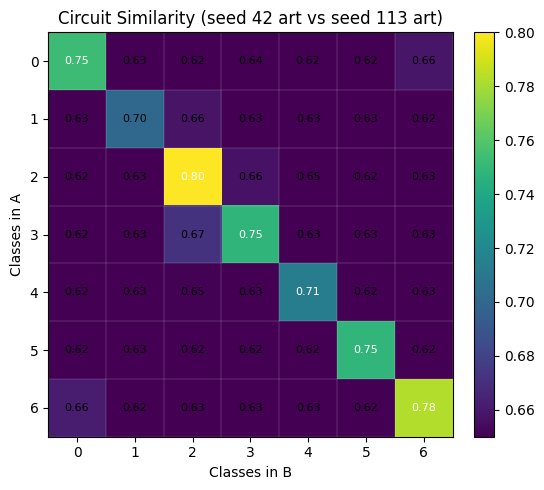

Frobenius norm: 4.143149515941359


In [29]:
%matplotlib inline
vA = build_class_vectors(circuits_art, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_photo, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=0.908, mean(off-diagonal)=0.831


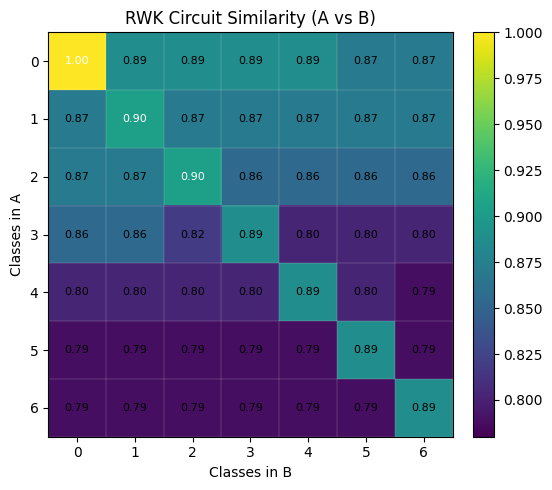

Frobenius norm: 5.395049967829027


In [30]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_art, circuits_photo,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 426.94it/s]
getting canonkeys: 3it [00:00, 12360.42it/s]

 --- treelet kernel matrix of size 2 built in 0.012319087982177734 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 562.47it/s]
getting canonkeys: 3it [00:00, 11366.68it/s]

 --- treelet kernel matrix of size 2 built in 0.010889768600463867 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 408.42it/s]
getting canonkeys: 3it [00:00, 3549.48it/s]

 --- treelet kernel matrix of size 2 built in 0.01249384880065918 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 453.24it/s]
getting canonkeys: 3it [00:00, 12384.76it/s]

 --- treelet kernel matrix of size 2 built in 0.01126241683959961 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 465.05it/s]
getting canonkeys: 3it [00:00, 12985.46it/s]

 --- treelet kernel matrix of size 2 built in 0.01141667366027832 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00

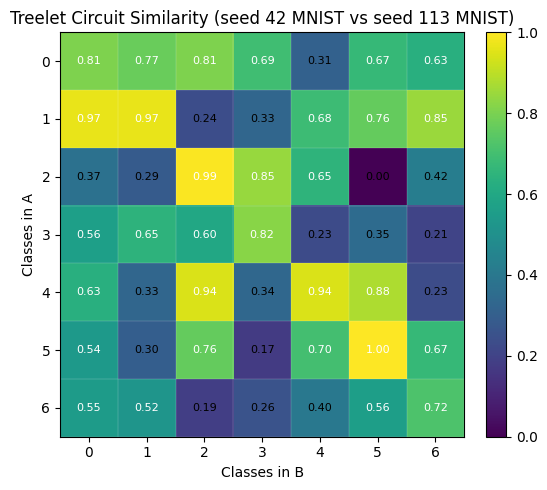

Frobenius norm: 3.7363139117635114


In [31]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_art, circuits_photo, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7616987953304856 mean offdiag: 0.6313342140121321


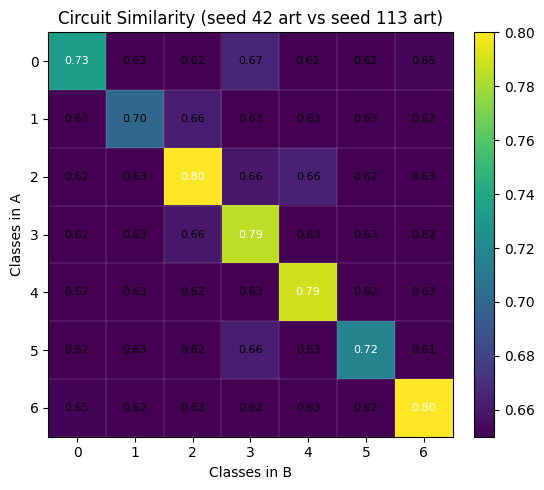

Frobenius norm: 4.142224457839613


In [32]:
%matplotlib inline
vA = build_class_vectors(circuits_art, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_mixup09, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=0.908, mean(off-diagonal)=0.831


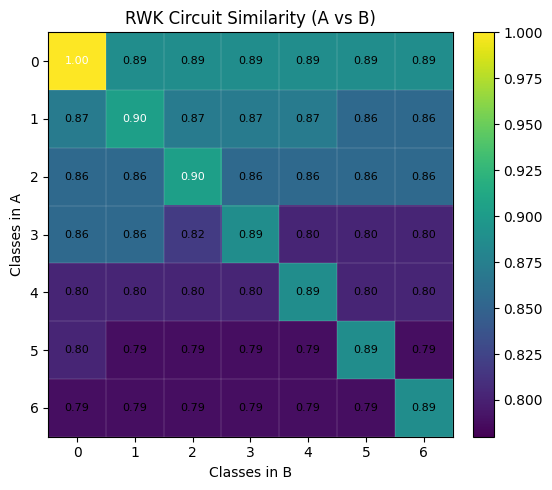

Frobenius norm: 5.394490841162674


In [33]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_art, circuits_mixup09,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 448.76it/s]
getting canonkeys: 3it [00:00, 11491.24it/s]

 --- treelet kernel matrix of size 2 built in 0.011670112609863281 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 466.22it/s]
getting canonkeys: 3it [00:00, 13039.29it/s]

 --- treelet kernel matrix of size 2 built in 0.011467933654785156 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 463.72it/s]
getting canonkeys: 3it [00:00, 13134.56it/s]

 --- treelet kernel matrix of size 2 built in 0.01133275032043457 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 464.92it/s]
getting canonkeys: 3it [00:00, 12879.13it/s]

 --- treelet kernel matrix of size 2 built in 0.011389970779418945 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 462.36it/s]
getting canonkeys: 3it [00:00, 12735.74it/s]

 --- treelet kernel matrix of size 2 built in 0.011761903762817383 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00

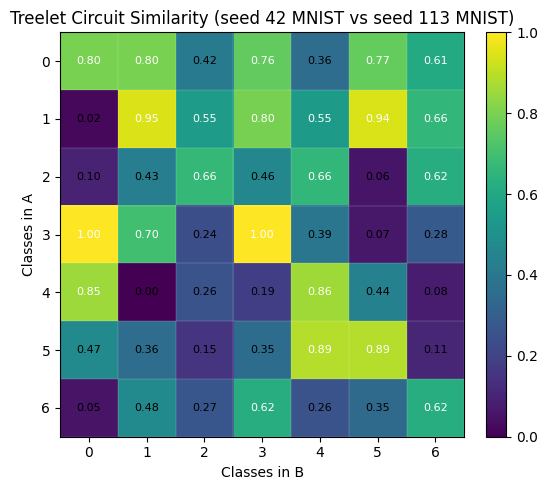

Frobenius norm: 3.4056576457031187


In [34]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_art, circuits_mixup09, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7646111469576098 mean offdiag: 0.6332244241236454


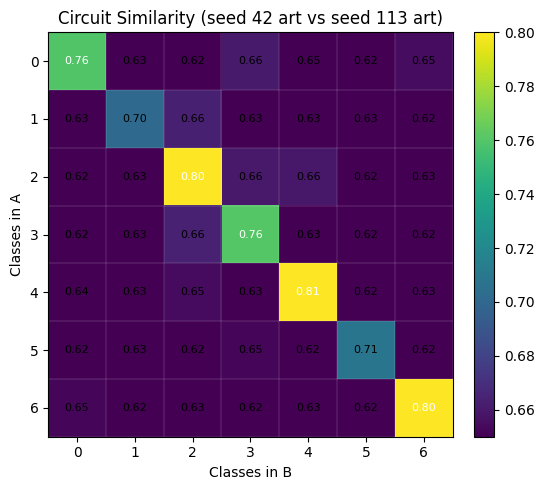

Frobenius norm: 4.153338295279946


In [35]:
%matplotlib inline
vA = build_class_vectors(circuits_art, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_mixup07, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=0.913, mean(off-diagonal)=0.834


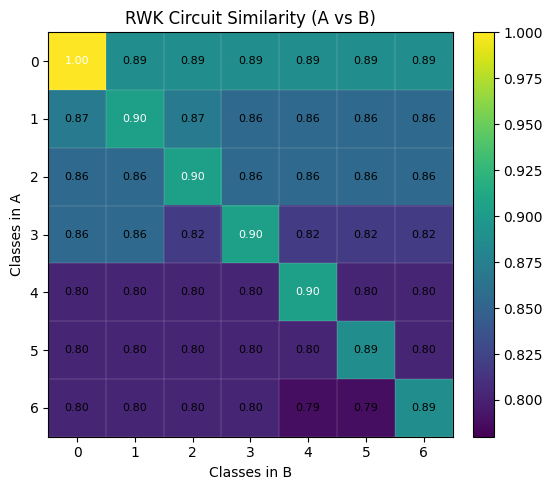

Frobenius norm: 5.4155230720322916


In [36]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_art, circuits_mixup07,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 452.22it/s]
getting canonkeys: 3it [00:00, 10582.77it/s]

 --- treelet kernel matrix of size 2 built in 0.012059211730957031 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 455.48it/s]
getting canonkeys: 3it [00:00, 14580.43it/s]

 --- treelet kernel matrix of size 2 built in 0.011386632919311523 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 1531.33it/s]
getting canonkeys: 3it [00:00, 35444.82it/s]

 --- treelet kernel matrix of size 2 built in 0.007275104522705078 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 1110.78it/s]
getting canonkeys: 3it [00:00, 22114.08it/s]

 --- treelet kernel matrix of size 2 built in 0.007829427719116211 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 821.45it/s]
getting canonkeys: 3it [00:00, 17026.94it/s]

 --- treelet kernel matrix of size 2 built in 0.008708953857421875 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 457.79it/s]
getting canonkeys: 3it [00:00, 11705.03it/s]

 --- treelet kernel matrix of size 2 built in 0.012096881866455078 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 455.38it/s]
getting canonkeys: 3it [00:00, 11814.94it/s]

 --- treelet kernel matrix of size 2 built in 0.012096405029296875 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 455.41it/s]
getting canonkeys: 3it [00:00, 12133.96it/s]

 --- treelet kernel matrix of size 2 built in 0.012357950210571289 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 458.44it/s]
getting canonkeys: 3it [00:00, 10745.44it/s]

 --- treelet kernel matrix of size 2 built in 0.012308359146118164 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 453.12it/s]
getting canonkeys: 3it [00:00, 11770.73it/s]

 --- treelet kernel matrix of size 2 built in 0.012586593627929688 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0

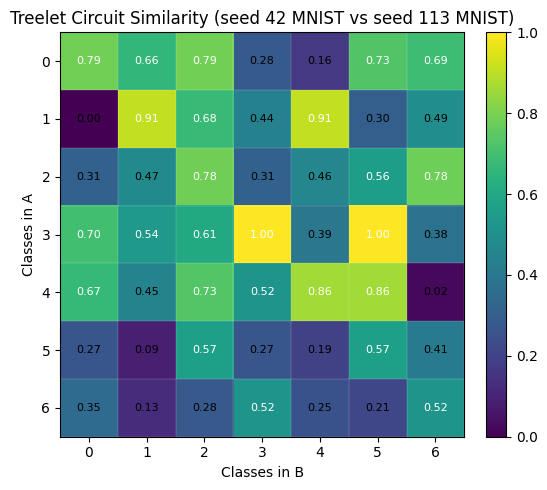

Frobenius norm: 3.462535585535637


In [37]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_art, circuits_mixup07, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7706713344938025 mean offdiag: 0.6357363833622217


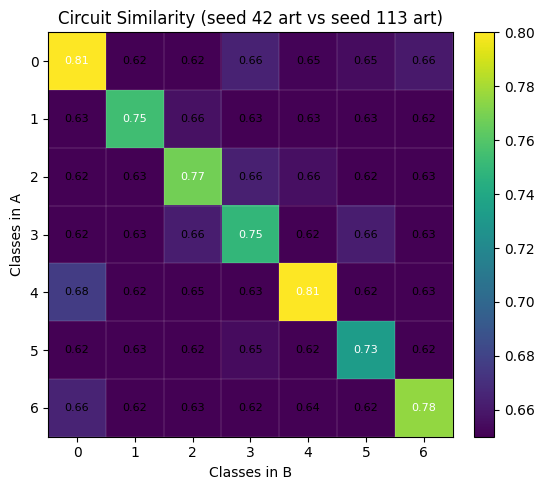

Frobenius norm: 4.166524340812792


In [38]:
%matplotlib inline
vA = build_class_vectors(circuits_art, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_mixup05, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=0.908, mean(off-diagonal)=0.835


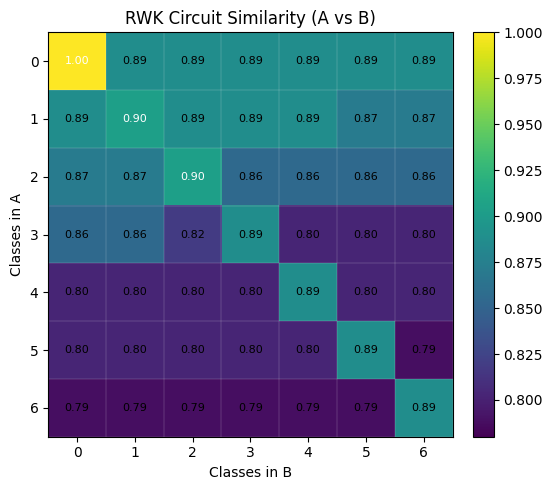

Frobenius norm: 5.423988234975593


In [39]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_art, circuits_mixup05,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 482.21it/s]
getting canonkeys: 3it [00:00, 12133.96it/s]

 --- treelet kernel matrix of size 2 built in 0.011093378067016602 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 464.85it/s]
getting canonkeys: 3it [00:00, 12264.05it/s]

 --- treelet kernel matrix of size 2 built in 0.011820316314697266 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 463.33it/s]
getting canonkeys: 3it [00:00, 12774.53it/s]

 --- treelet kernel matrix of size 2 built in 0.011618375778198242 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 442.23it/s]
getting canonkeys: 3it [00:00, 12620.77it/s]

 --- treelet kernel matrix of size 2 built in 0.012051105499267578 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 456.90it/s]
getting canonkeys: 3it [00:00, 12582.91it/s]

 --- treelet kernel matrix of size 2 built in 0.011557340621948242 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0

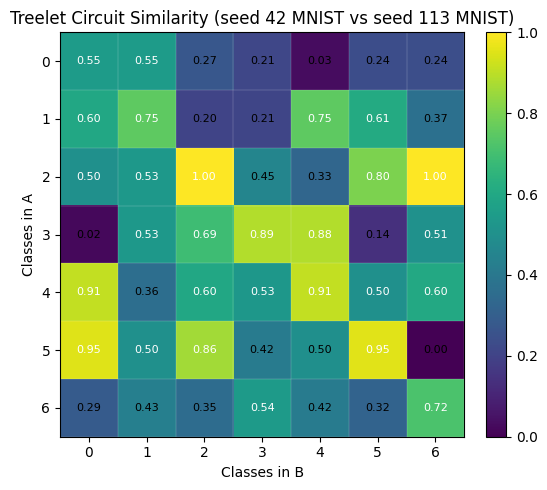

Frobenius norm: 3.497033833747721


In [40]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_art, circuits_mixup05, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7658344679416299 mean offdiag: 0.6345100227832922


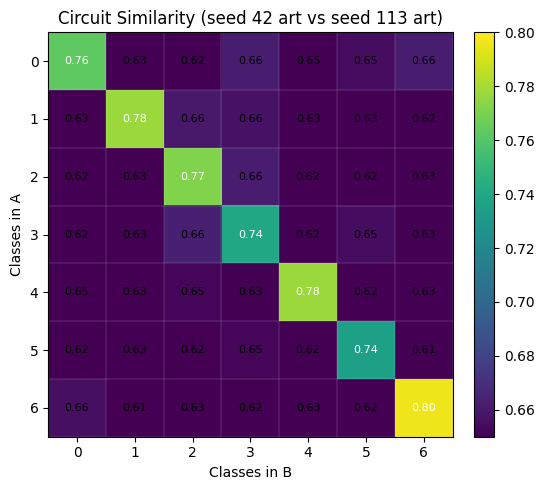

Frobenius norm: 4.1600591476685835


In [41]:
%matplotlib inline
vA = build_class_vectors(circuits_art, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_mixup03, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=0.908, mean(off-diagonal)=0.834


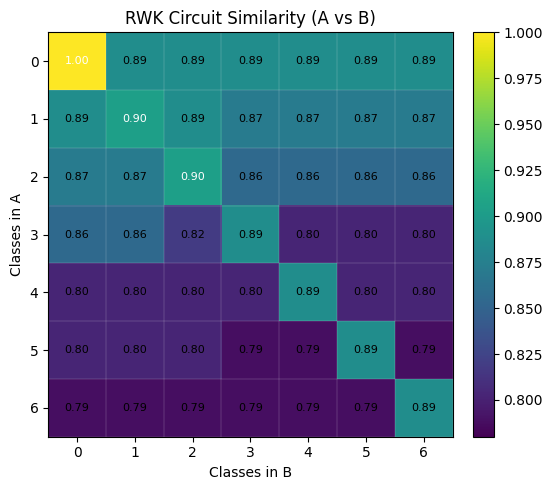

Frobenius norm: 5.414359331188357


In [42]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_art, circuits_mixup03,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 487.12it/s]
getting canonkeys: 3it [00:00, 3993.31it/s]

 --- treelet kernel matrix of size 2 built in 0.012107372283935547 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 452.68it/s]
getting canonkeys: 3it [00:00, 10856.70it/s]

 --- treelet kernel matrix of size 2 built in 0.01126241683959961 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 460.15it/s]
getting canonkeys: 3it [00:00, 12826.62it/s]

 --- treelet kernel matrix of size 2 built in 0.011922836303710938 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 457.92it/s]
getting canonkeys: 3it [00:00, 11650.84it/s]

 --- treelet kernel matrix of size 2 built in 0.011320114135742188 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 452.29it/s]
getting canonkeys: 3it [00:00, 10951.19it/s]

 --- treelet kernel matrix of size 2 built in 0.011996984481811523 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<


getting canonkeys: 3it [00:00, 12240.19it/s]

 --- treelet kernel matrix of size 2 built in 0.012258291244506836 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 452.83it/s]
getting canonkeys: 3it [00:00, 11837.17it/s]

 --- treelet kernel matrix of size 2 built in 0.012324333190917969 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 460.81it/s]
getting canonkeys: 3it [00:00, 12006.60it/s]

 --- treelet kernel matrix of size 2 built in 0.012114524841308594 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 462.00it/s]
getting canonkeys: 3it [00:00, 12252.11it/s]

 --- treelet kernel matrix of size 2 built in 0.011936187744140625 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 460.94it/s]
getting canonkeys: 3it [00:00, 11938.25it/s]

 --- treelet kernel matrix of size 2 built in 0.011981964111328125 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 458.97it/s]
getting canonkeys: 3it [00:00, 12157.40it/s]

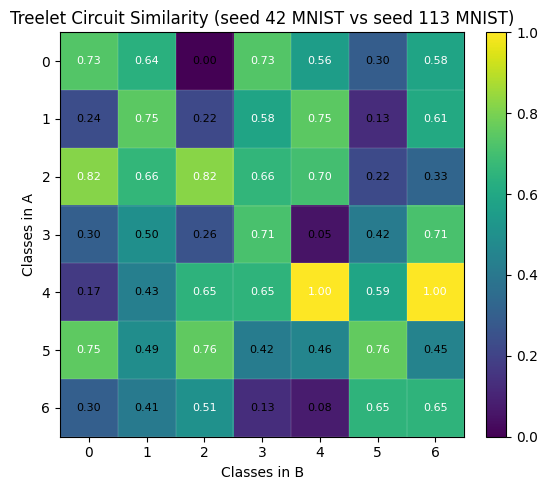

Frobenius norm: 3.4773495744410234


In [43]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_art, circuits_mixup03, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7649790880520058 mean offdiag: 0.6327880984996678


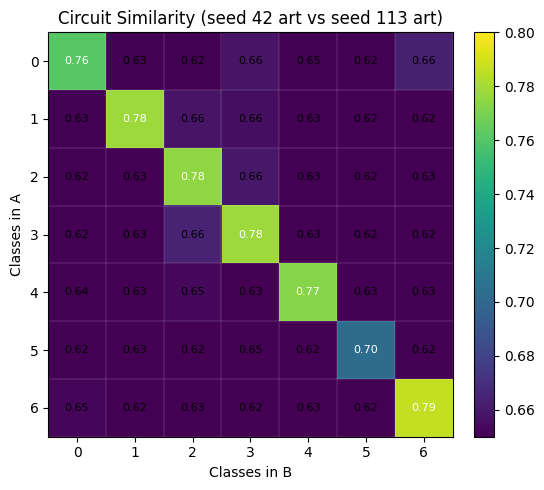

Frobenius norm: 4.149400953621918


In [44]:
%matplotlib inline
vA = build_class_vectors(circuits_art, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_mixup01, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=0.939, mean(off-diagonal)=0.867


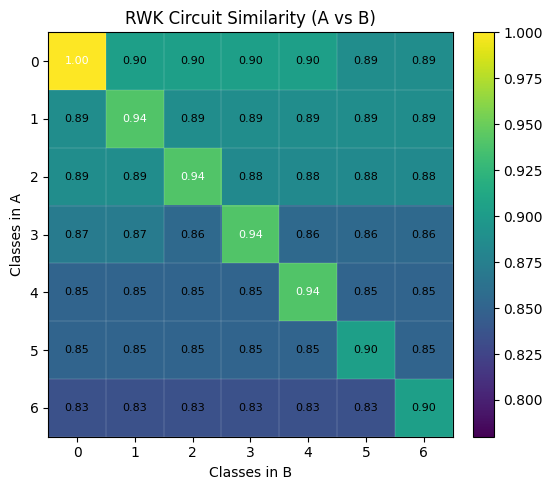

Frobenius norm: 5.623658868951977


In [45]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_art, circuits_mixup01,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 453.81it/s]
getting canonkeys: 3it [00:00, 9091.70it/s]

 --- treelet kernel matrix of size 2 built in 0.011459589004516602 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 663.71it/s]
getting canonkeys: 3it [00:00, 4109.38it/s]

 --- treelet kernel matrix of size 2 built in 0.010853767395019531 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 464.43it/s]
getting canonkeys: 3it [00:00, 12985.46it/s]

 --- treelet kernel matrix of size 2 built in 0.011044025421142578 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 462.82it/s]
getting canonkeys: 3it [00:00, 13414.62it/s]

 --- treelet kernel matrix of size 2 built in 0.01165771484375 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 452.83it/s]
getting canonkeys: 3it [00:00, 12608.13it/s]

 --- treelet kernel matrix of size 2 built in 0.011498689651489258 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:0

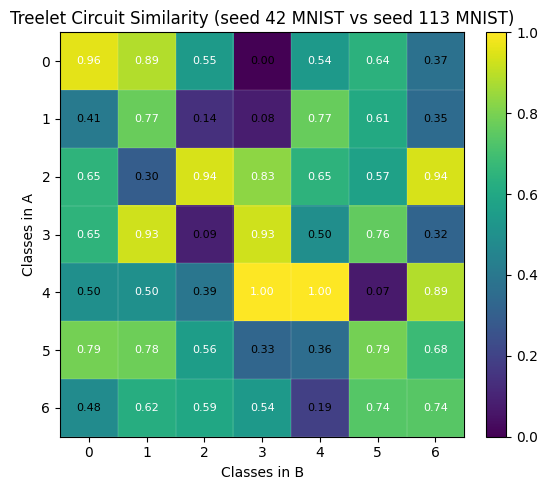

Frobenius norm: 3.866954344294349


In [46]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_art, circuits_mixup03, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.8292902517937488 mean offdiag: 0.6349286208368576


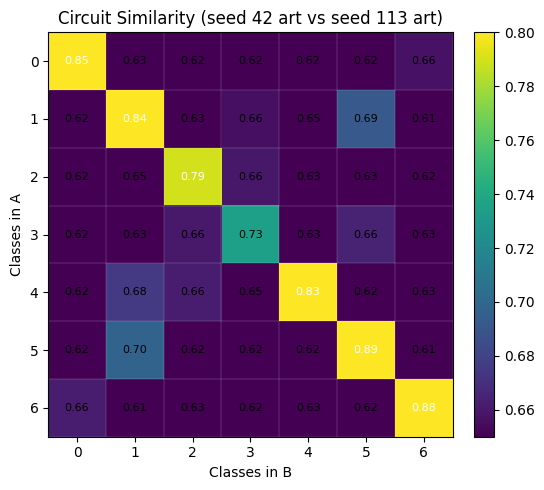

Frobenius norm: 4.143920318609134


In [47]:
%matplotlib inline
vA = build_class_vectors(circuits_mixup09, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_mixup07, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=0.984, mean(off-diagonal)=0.947


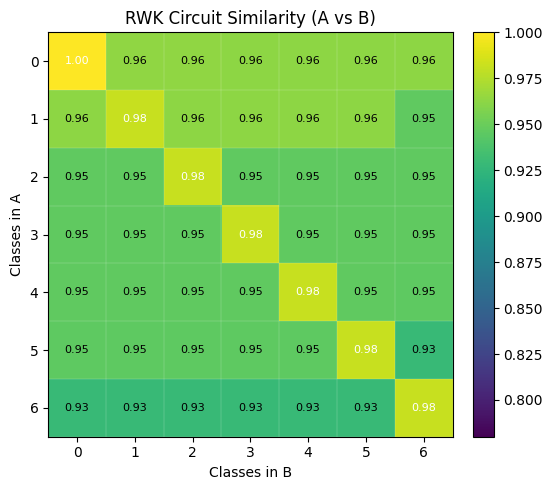

Frobenius norm: 6.139958711522656


In [48]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_mixup09, circuits_mixup07,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 442.25it/s]
getting canonkeys: 3it [00:00, 11803.86it/s]

 --- treelet kernel matrix of size 2 built in 0.011846542358398438 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 430.96it/s]
getting canonkeys: 3it [00:00, 12360.42it/s]

 --- treelet kernel matrix of size 2 built in 0.01149892807006836 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 459.30it/s]
getting canonkeys: 3it [00:00, 12892.33it/s]

 --- treelet kernel matrix of size 2 built in 0.011301517486572266 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 446.49it/s]
getting canonkeys: 3it [00:00, 12180.94it/s]

 --- treelet kernel matrix of size 2 built in 0.012410879135131836 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 457.74it/s]
getting canonkeys: 3it [00:00, 12697.19it/s]

 --- treelet kernel matrix of size 2 built in 0.01046609878540039 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<

getting canonkeys: 3it [00:00, 16320.25it/s]

 --- treelet kernel matrix of size 2 built in 0.012124061584472656 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 788.33it/s]
getting canonkeys: 3it [00:00, 17747.41it/s]

 --- treelet kernel matrix of size 2 built in 0.009249687194824219 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 753.96it/s]
getting canonkeys: 3it [00:00, 16935.28it/s]

 --- treelet kernel matrix of size 2 built in 0.009737253189086914 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 786.11it/s]
getting canonkeys: 3it [00:00, 17549.39it/s]

 --- treelet kernel matrix of size 2 built in 0.009730339050292969 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 785.01it/s]
getting canonkeys: 3it [00:00, 18131.00it/s]

 --- treelet kernel matrix of size 2 built in 0.009313583374023438 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 794.23it/s]
getting canonkeys: 3it [00:00, 18157.16it/s]


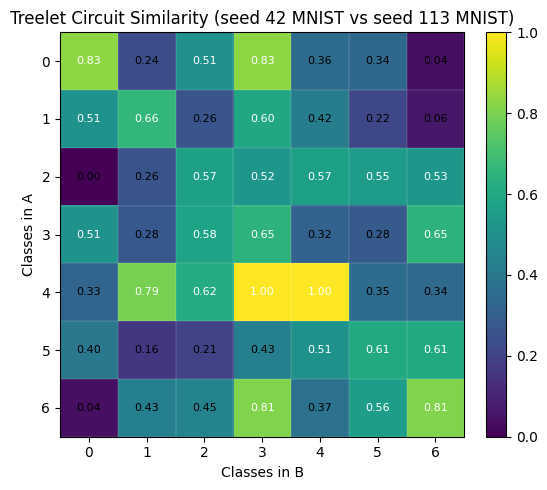

Frobenius norm: 3.1980252674748746


In [49]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mixup09, circuits_mixup07, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.790746258347202 mean offdiag: 0.6352458509233759


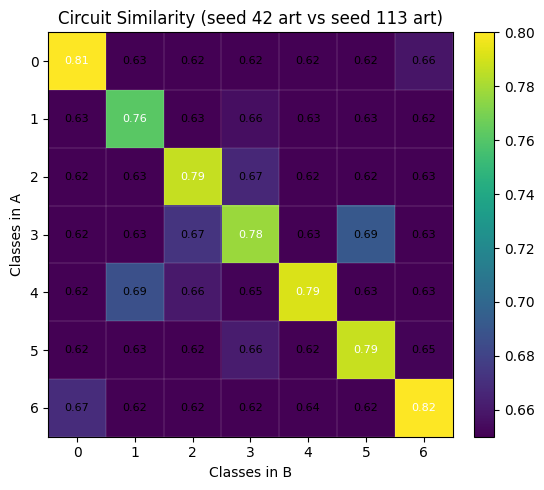

Frobenius norm: 4.156194240075649


In [50]:
%matplotlib inline
vA = build_class_vectors(circuits_mixup09, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_mixup05, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.994


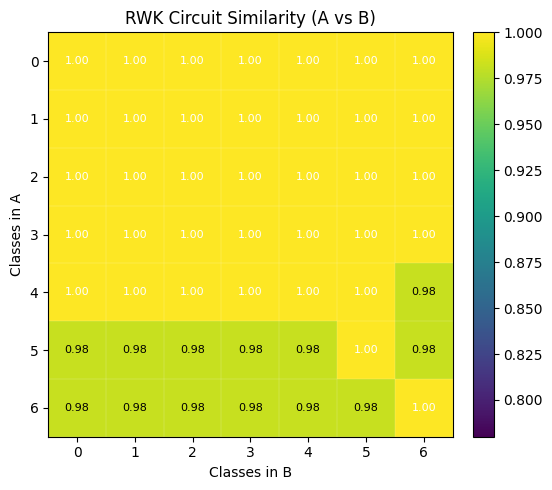

Frobenius norm: 6.444133297952993


In [51]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_mixup09, circuits_mixup05,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 441.71it/s]
getting canonkeys: 3it [00:00, 12180.94it/s]

 --- treelet kernel matrix of size 2 built in 0.012000799179077148 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 391.83it/s]
getting canonkeys: 3it [00:00, 12761.57it/s]

 --- treelet kernel matrix of size 2 built in 0.012029170989990234 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 469.14it/s]
getting canonkeys: 3it [00:00, 11366.68it/s]

 --- treelet kernel matrix of size 2 built in 0.011447429656982422 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 466.32it/s]
getting canonkeys: 3it [00:00, 12998.88it/s]

 --- treelet kernel matrix of size 2 built in 0.01187753677368164 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 462.85it/s]
getting canonkeys: 3it [00:00, 12826.62it/s]

 --- treelet kernel matrix of size 2 built in 0.011228084564208984 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00

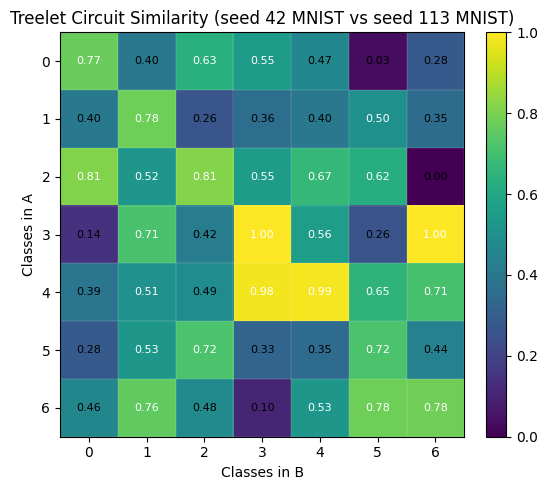

Frobenius norm: 3.4962613535205236


In [52]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mixup09, circuits_mixup05, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7733099702449675 mean offdiag: 0.6321193608683645


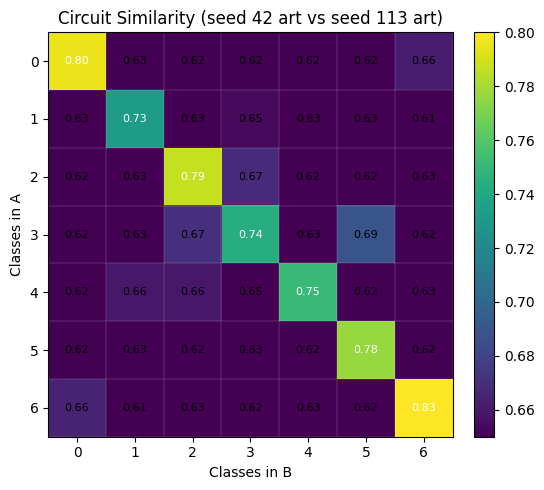

Frobenius norm: 4.142686778577486


In [53]:
%matplotlib inline
vA = build_class_vectors(circuits_mixup09, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_mixup03, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.990


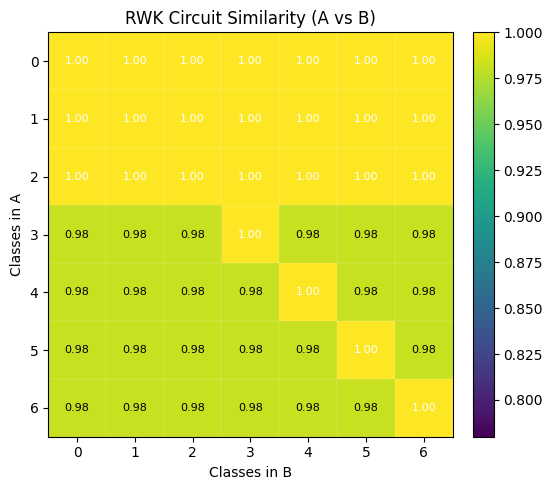

Frobenius norm: 6.4129945908101105


In [54]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_mixup09, circuits_mixup03,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 444.24it/s]
getting canonkeys: 3it [00:00, 11848.32it/s]

 --- treelet kernel matrix of size 2 built in 0.011651277542114258 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 459.88it/s]
getting canonkeys: 3it [00:00, 12998.88it/s]

 --- treelet kernel matrix of size 2 built in 0.011353015899658203 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 458.85it/s]
getting canonkeys: 3it [00:00, 11586.48it/s]

 --- treelet kernel matrix of size 2 built in 0.011842012405395508 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 455.46it/s]
getting canonkeys: 3it [00:00, 12800.52it/s]

 --- treelet kernel matrix of size 2 built in 0.01107645034790039 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 456.10it/s]
getting canonkeys: 3it [00:00, 3824.59it/s]

 --- treelet kernel matrix of size 2 built in 0.012382745742797852 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 410.64it/s]
getting canonkeys: 3it [00:00, 11881.88it/s]

 --- treelet kernel matrix of size 2 built in 0.01316380500793457 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 455.06it/s]
getting canonkeys: 3it [00:00, 11295.25it/s]

 --- treelet kernel matrix of size 2 built in 0.012540340423583984 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 455.61it/s]
getting canonkeys: 3it [00:00, 11737.79it/s]

 --- treelet kernel matrix of size 2 built in 0.011820793151855469 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 459.15it/s]
getting canonkeys: 3it [00:00, 10609.54it/s]

 --- treelet kernel matrix of size 2 built in 0.012095928192138672 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 458.72it/s]
getting canonkeys: 3it [00:00, 11640.07it/s]

 --- treelet kernel matrix of size 2 built in 0.011772632598876953 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00

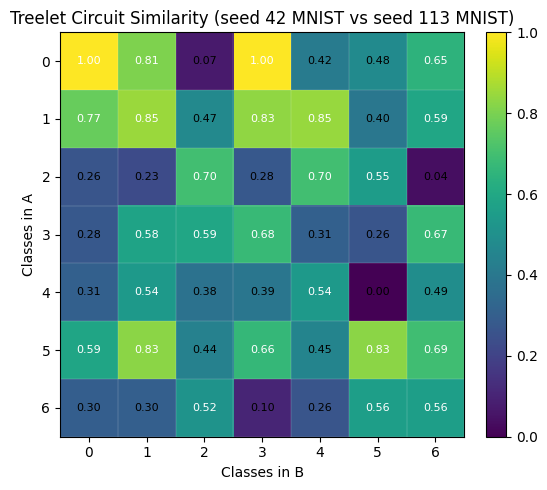

Frobenius norm: 3.5118216869323624


In [55]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mixup09, circuits_mixup03, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7762947594241174 mean offdiag: 0.6308341288800517


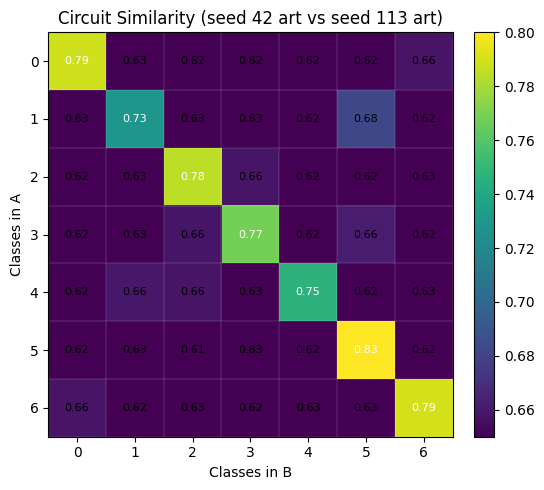

Frobenius norm: 4.13291857634933


In [56]:
%matplotlib inline
vA = build_class_vectors(circuits_mixup09, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_mixup01, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=0.984, mean(off-diagonal)=0.932


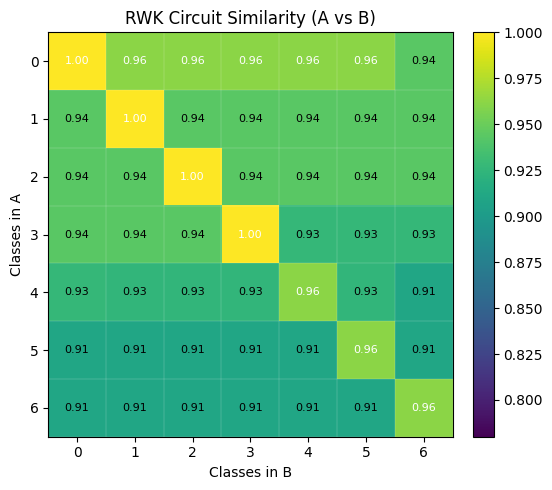

Frobenius norm: 6.041558401761082


In [57]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_mixup09, circuits_mixup01,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 449.29it/s]
getting canonkeys: 3it [00:00, 12041.06it/s]

 --- treelet kernel matrix of size 2 built in 0.01171112060546875 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 450.44it/s]
getting canonkeys: 3it [00:00, 12288.00it/s]

 --- treelet kernel matrix of size 2 built in 0.01159524917602539 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 459.22it/s]
getting canonkeys: 3it [00:00, 3758.34it/s]

 --- treelet kernel matrix of size 2 built in 0.012161731719970703 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 460.84it/s]
getting canonkeys: 3it [00:00, 4271.19it/s]

 --- treelet kernel matrix of size 2 built in 0.011516332626342773 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 390.04it/s]
getting canonkeys: 3it [00:00, 12646.14it/s]

 --- treelet kernel matrix of size 2 built in 0.01149749755859375 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 460.91it/s]
getting canonkeys: 3it [00:00, 12145.67it/s]

 --- treelet kernel matrix of size 2 built in 0.01195216178894043 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 430.60it/s]
getting canonkeys: 3it [00:00, 3441.72it/s]

 --- treelet kernel matrix of size 2 built in 0.013280153274536133 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 460.48it/s]
getting canonkeys: 3it [00:00, 11926.93it/s]

 --- treelet kernel matrix of size 2 built in 0.011360406875610352 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 461.52it/s]
getting canonkeys: 3it [00:00, 11759.73it/s]

 --- treelet kernel matrix of size 2 built in 0.011839151382446289 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 392.96it/s]
getting canonkeys: 3it [00:00, 12064.15it/s]

 --- treelet kernel matrix of size 2 built in 0.01251840591430664 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<0

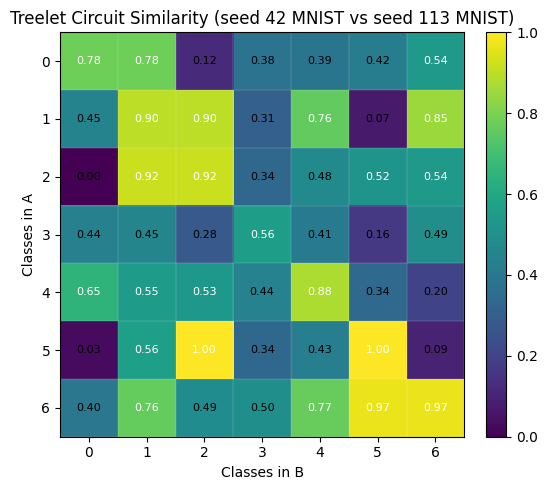

Frobenius norm: 3.5315603564405795


In [58]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mixup09, circuits_mixup01, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7640682414490383 mean offdiag: 0.6315415575616248


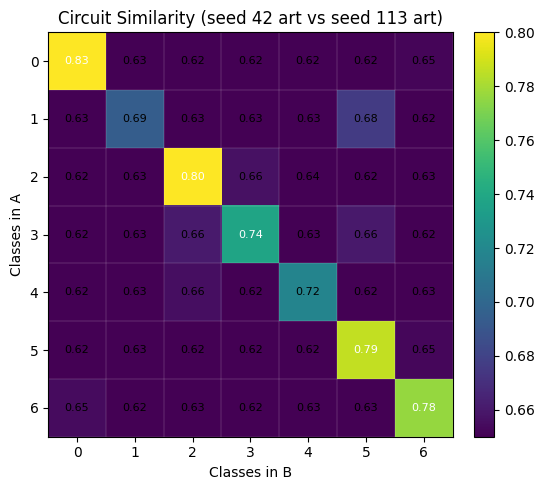

Frobenius norm: 4.14296102292587


In [59]:
%matplotlib inline
vA = build_class_vectors(circuits_mixup09, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_photo, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.978


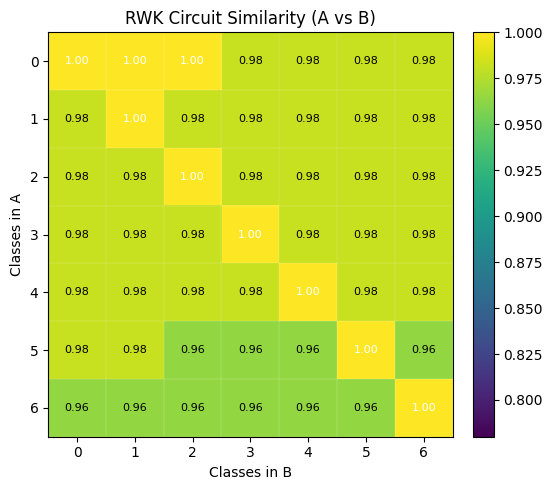

Frobenius norm: 6.3403249462952855


In [60]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_mixup09, circuits_photo,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 473.53it/s]
getting canonkeys: 3it [00:00, 11214.72it/s]

 --- treelet kernel matrix of size 2 built in 0.011718988418579102 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 438.09it/s]
getting canonkeys: 3it [00:00, 12396.96it/s]

 --- treelet kernel matrix of size 2 built in 0.012388944625854492 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 462.74it/s]
getting canonkeys: 3it [00:00, 12865.96it/s]

 --- treelet kernel matrix of size 2 built in 0.011379003524780273 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 458.04it/s]
getting canonkeys: 3it [00:00, 12958.71it/s]

 --- treelet kernel matrix of size 2 built in 0.011488914489746094 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 455.70it/s]
getting canonkeys: 3it [00:00, 12495.44it/s]

 --- treelet kernel matrix of size 2 built in 0.011525630950927734 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0

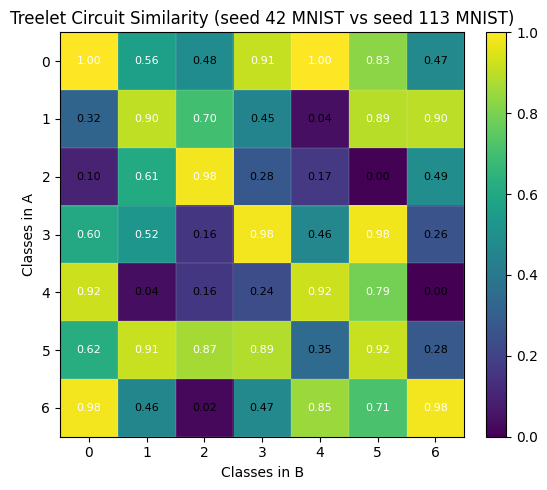

Frobenius norm: 3.9357770807060994


In [61]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mixup09, circuits_photo, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.8144509467891774 mean offdiag: 0.6376736469911257


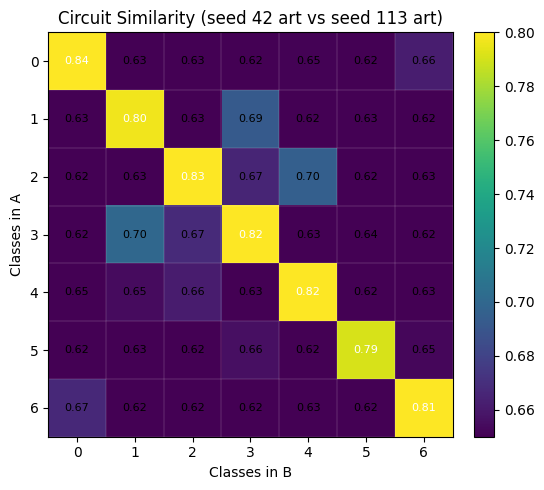

Frobenius norm: 4.164362272224315


In [62]:
%matplotlib inline
vA = build_class_vectors(circuits_mixup07, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_mixup05, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=0.984, mean(off-diagonal)=0.960


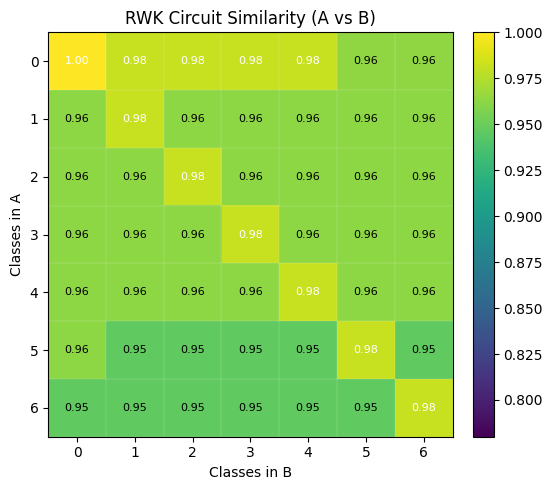

Frobenius norm: 6.223493240696985


In [63]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_mixup07, circuits_mixup05,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 577.33it/s]
getting canonkeys: 3it [00:00, 14169.95it/s]

 --- treelet kernel matrix of size 2 built in 0.010933876037597656 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 465.98it/s]
getting canonkeys: 3it [00:00, 12918.80it/s]

 --- treelet kernel matrix of size 2 built in 0.01091146469116211 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 453.66it/s]
getting canonkeys: 3it [00:00, 12958.71it/s]

 --- treelet kernel matrix of size 2 built in 0.01148080825805664 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 450.13it/s]
getting canonkeys: 3it [00:00, 12684.39it/s]

 --- treelet kernel matrix of size 2 built in 0.011730432510375977 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 464.74it/s]
getting canonkeys: 3it [00:00, 12892.33it/s]

 --- treelet kernel matrix of size 2 built in 0.0113372802734375 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00

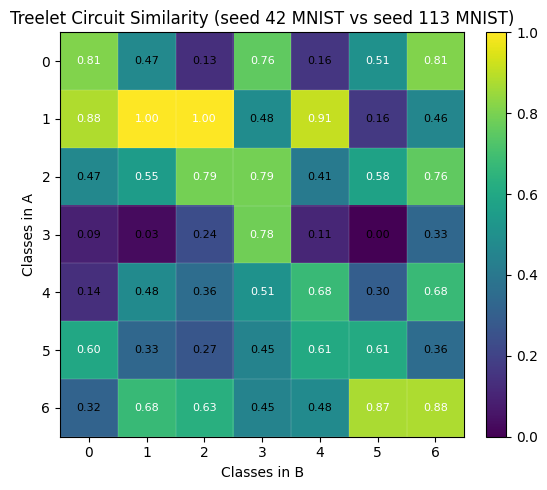

Frobenius norm: 3.4950614114752794


In [64]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mixup07, circuits_mixup05, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7954530684835845 mean offdiag: 0.6332236659764335


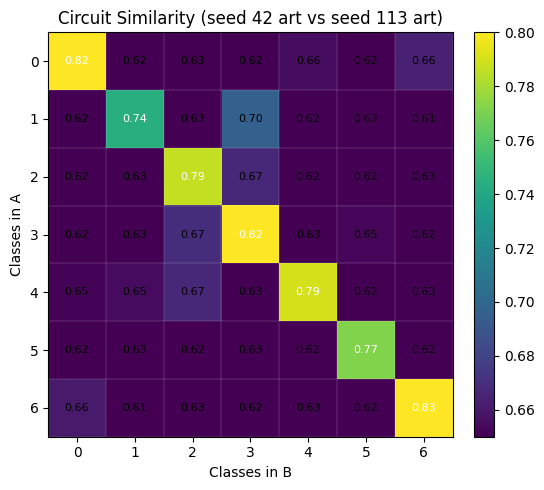

Frobenius norm: 4.141762182503007


In [65]:
%matplotlib inline
vA = build_class_vectors(circuits_mixup07, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_mixup03, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=0.984, mean(off-diagonal)=0.956


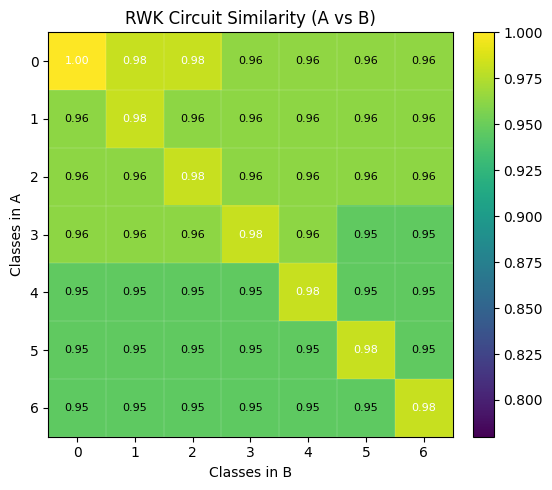

Frobenius norm: 6.193681283963827


In [66]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_mixup07, circuits_mixup03,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 449.29it/s]
getting canonkeys: 3it [00:00, 11737.79it/s]

 --- treelet kernel matrix of size 2 built in 0.011980533599853516 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 468.32it/s]
getting canonkeys: 3it [00:00, 12839.71it/s]

 --- treelet kernel matrix of size 2 built in 0.011979103088378906 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 452.97it/s]
getting canonkeys: 3it [00:00, 12633.45it/s]

 --- treelet kernel matrix of size 2 built in 0.011028528213500977 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 457.94it/s]
getting canonkeys: 3it [00:00, 12761.57it/s]

 --- treelet kernel matrix of size 2 built in 0.011954307556152344 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 455.28it/s]
getting canonkeys: 3it [00:00, 12110.60it/s]

 --- treelet kernel matrix of size 2 built in 0.011351823806762695 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0



 --- treelet kernel matrix of size 2 built in 0.012090682983398438 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 449.79it/s]
getting canonkeys: 3it [00:00, 12064.15it/s]

 --- treelet kernel matrix of size 2 built in 0.01209259033203125 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 437.48it/s]
getting canonkeys: 3it [00:00, 11837.17it/s]

 --- treelet kernel matrix of size 2 built in 0.012525081634521484 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 459.07it/s]
getting canonkeys: 3it [00:00, 11275.01it/s]

 --- treelet kernel matrix of size 2 built in 0.0117340087890625 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 460.38it/s]
getting canonkeys: 3it [00:00, 12252.11it/s]

 --- treelet kernel matrix of size 2 built in 0.011667490005493164 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 457.59it/s]
getting canonkeys: 3it [00:00, 8383.02it/s]

 --- treelet kernel matrix of size 2 built in 0

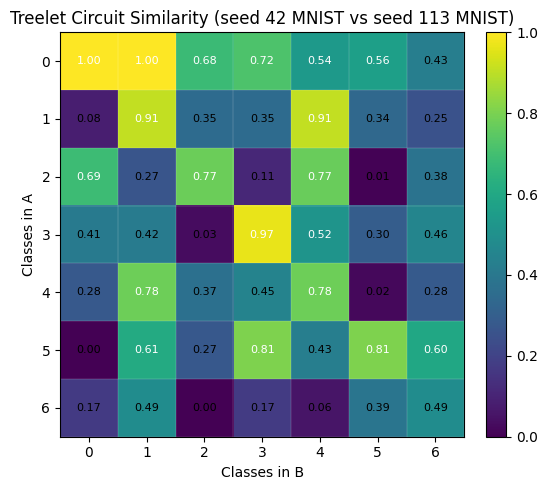

Frobenius norm: 3.1342438141919016


In [67]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mixup07, circuits_mixup03, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7876910524204471 mean offdiag: 0.633440283604106


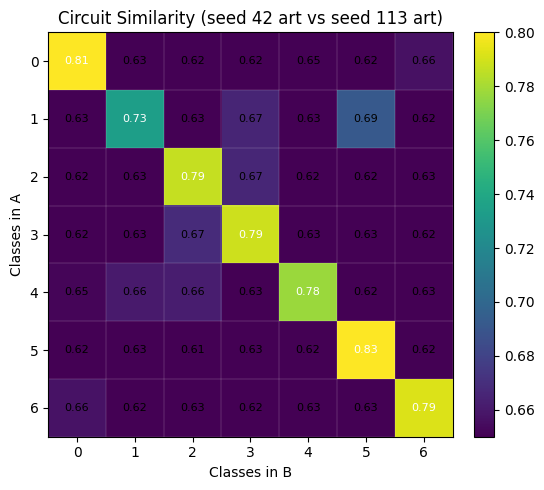

Frobenius norm: 4.145614590966534


In [68]:
%matplotlib inline
vA = build_class_vectors(circuits_mixup07, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_mixup01, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=0.984, mean(off-diagonal)=0.934


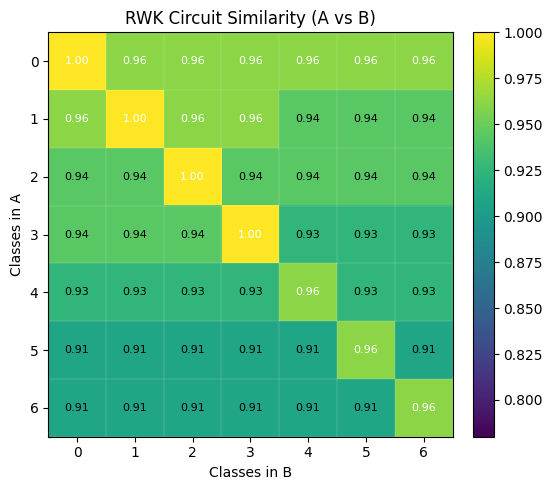

Frobenius norm: 6.05442359490337


In [69]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_mixup07, circuits_mixup01,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 479.95it/s]
getting canonkeys: 3it [00:00, 11859.48it/s]

 --- treelet kernel matrix of size 2 built in 0.011311531066894531 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 452.29it/s]
getting canonkeys: 3it [00:00, 12918.80it/s]

 --- treelet kernel matrix of size 2 built in 0.011818408966064453 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 465.03it/s]
getting canonkeys: 3it [00:00, 13039.29it/s]

 --- treelet kernel matrix of size 2 built in 0.011312007904052734 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 468.32it/s]
getting canonkeys: 3it [00:00, 12932.08it/s]

 --- treelet kernel matrix of size 2 built in 0.011390209197998047 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 457.57it/s]
getting canonkeys: 3it [00:00, 12570.34it/s]

 --- treelet kernel matrix of size 2 built in 0.012151479721069336 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0

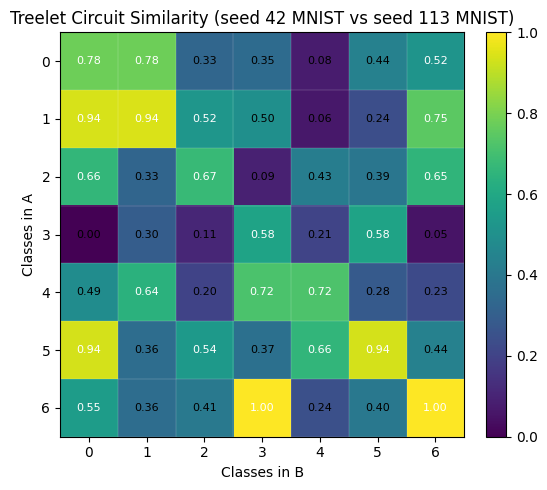

Frobenius norm: 3.278534950951092


In [70]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mixup07, circuits_mixup01, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7570414795734844 mean offdiag: 0.6315885954614752


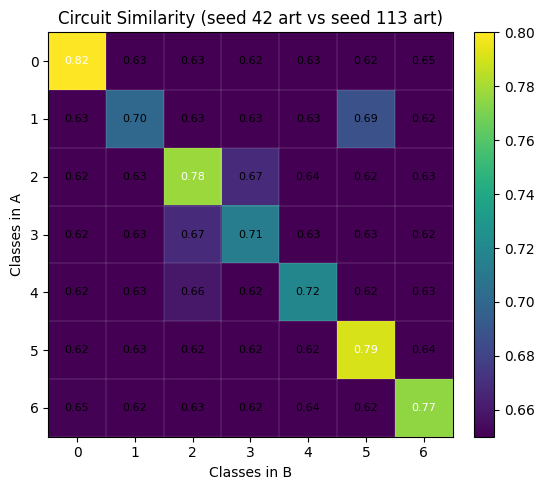

Frobenius norm: 4.1460848553263245


In [71]:
%matplotlib inline
vA = build_class_vectors(circuits_mixup07, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_photo, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=0.979, mean(off-diagonal)=0.949


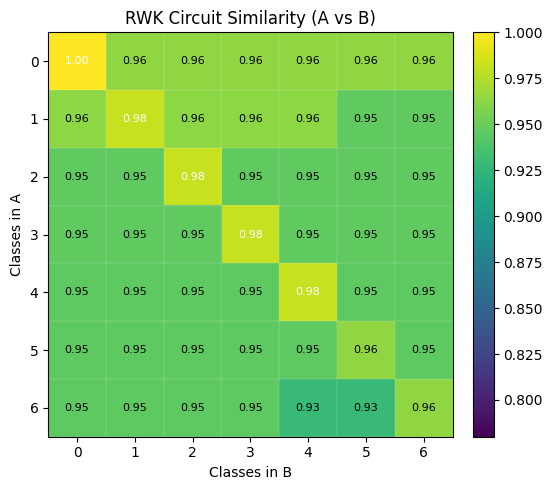

Frobenius norm: 6.150182020481431


In [72]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_mixup07, circuits_photo,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 448.32it/s]
getting canonkeys: 3it [00:00, 12483.05it/s]

 --- treelet kernel matrix of size 2 built in 0.011748552322387695 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 462.64it/s]
getting canonkeys: 3it [00:00, 13079.95it/s]

 --- treelet kernel matrix of size 2 built in 0.011359214782714844 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 457.74it/s]
getting canonkeys: 3it [00:00, 12761.57it/s]

 --- treelet kernel matrix of size 2 built in 0.011865615844726562 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 394.37it/s]
getting canonkeys: 3it [00:00, 12879.13it/s]

 --- treelet kernel matrix of size 2 built in 0.011659622192382812 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 464.13it/s]
getting canonkeys: 3it [00:00, 12658.87it/s]

 --- treelet kernel matrix of size 2 built in 0.011507987976074219 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0

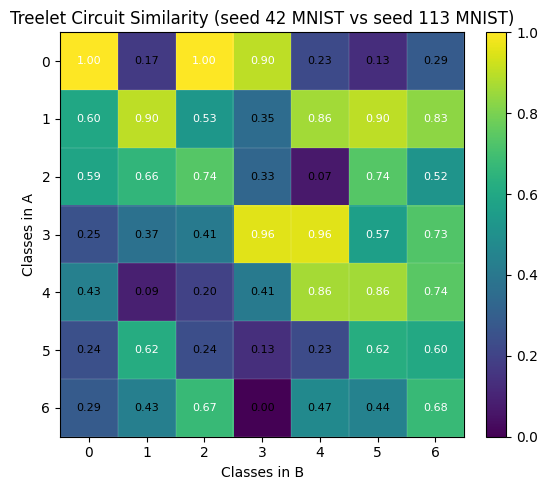

Frobenius norm: 3.5996592970850636


In [73]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mixup07, circuits_photo, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.8385996587038298 mean offdiag: 0.6390502041230752


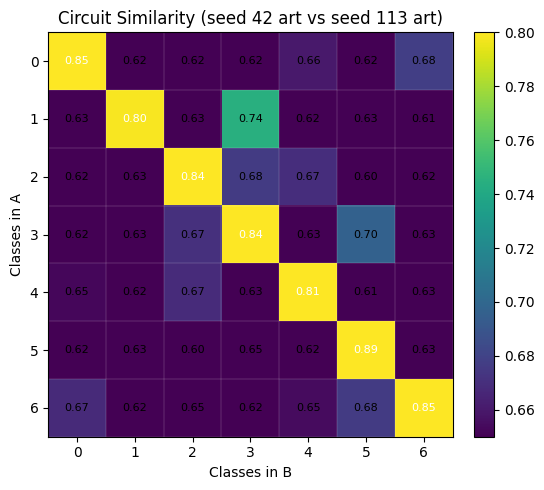

Frobenius norm: 4.16800587191479


In [74]:
%matplotlib inline
vA = build_class_vectors(circuits_mixup05, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_mixup03, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=1.000


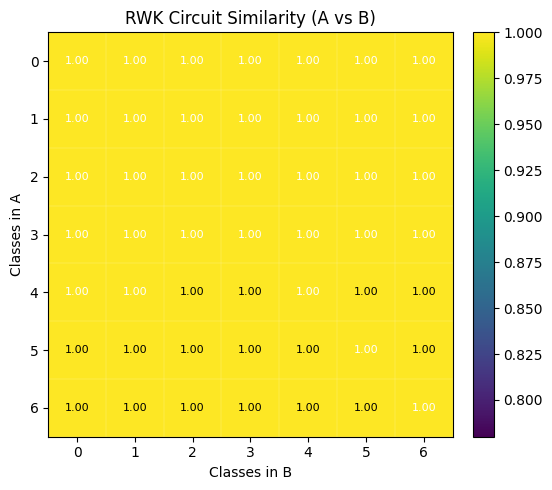

Frobenius norm: 6.4807406984078595


In [75]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_mixup05, circuits_mixup03,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 485.79it/s]
getting canonkeys: 3it [00:00, 12240.19it/s]

 --- treelet kernel matrix of size 2 built in 0.011299371719360352 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 352.52it/s]
getting canonkeys: 3it [00:00, 12892.33it/s]

 --- treelet kernel matrix of size 2 built in 0.012771368026733398 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 457.52it/s]
getting canonkeys: 3it [00:00, 12312.05it/s]

 --- treelet kernel matrix of size 2 built in 0.011303901672363281 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 460.08it/s]
getting canonkeys: 3it [00:00, 13107.20it/s]

 --- treelet kernel matrix of size 2 built in 0.011378049850463867 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 451.97it/s]
getting canonkeys: 3it [00:00, 13052.81it/s]

 --- treelet kernel matrix of size 2 built in 0.011478662490844727 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0

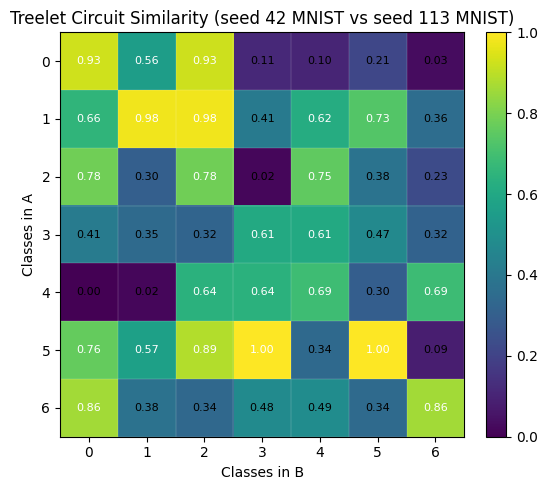

Frobenius norm: 3.533682900691858


In [76]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mixup05, circuits_mixup03, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.8059106643485172 mean offdiag: 0.6358955513987828


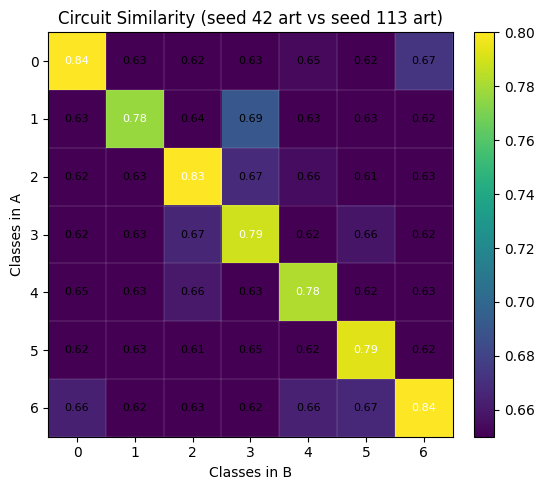

Frobenius norm: 4.155350689082151


In [77]:
%matplotlib inline
vA = build_class_vectors(circuits_mixup05, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_mixup01, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 906.09it/s]
getting canonkeys: 3it [00:00, 21472.55it/s]

 --- treelet kernel matrix of size 2 built in 0.008414268493652344 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 671.25it/s]
getting canonkeys: 3it [00:00, 18396.07it/s]

 --- treelet kernel matrix of size 2 built in 0.009338140487670898 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 494.90it/s]
getting canonkeys: 3it [00:00, 12787.51it/s]

 --- treelet kernel matrix of size 2 built in 0.011336565017700195 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 465.44it/s]
getting canonkeys: 3it [00:00, 13245.17it/s]

 --- treelet kernel matrix of size 2 built in 0.01126551628112793 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 456.18it/s]
getting canonkeys: 3it [00:00, 13052.81it/s]

 --- treelet kernel matrix of size 2 built in 0.011308431625366211 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00

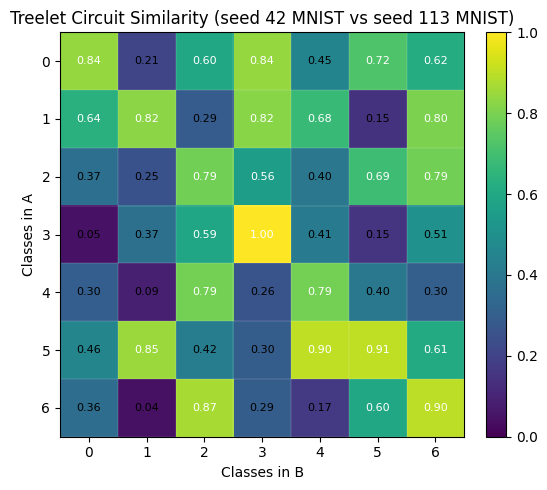

Frobenius norm: 3.4857565596810782


In [78]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mixup05, circuits_mixup01, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7545567442227518 mean offdiag: 0.6324794254124773


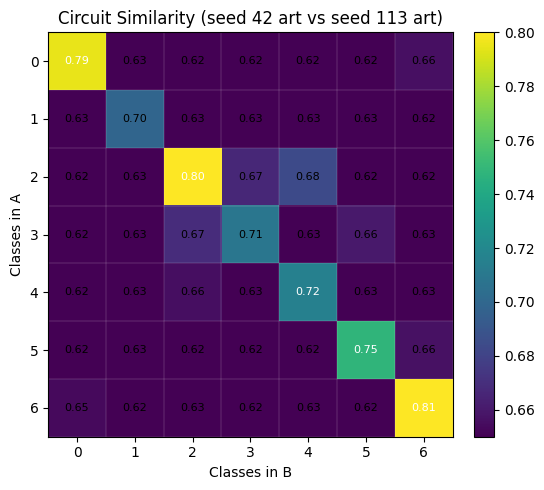

Frobenius norm: 4.153010061919094


In [79]:
%matplotlib inline
vA = build_class_vectors(circuits_mixup05, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_photo, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 453.76it/s]
getting canonkeys: 3it [00:00, 12722.86it/s]

 --- treelet kernel matrix of size 2 built in 0.011619091033935547 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 459.65it/s]
getting canonkeys: 3it [00:00, 13148.29it/s]

 --- treelet kernel matrix of size 2 built in 0.00938105583190918 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 450.32it/s]
getting canonkeys: 3it [00:00, 12865.96it/s]

 --- treelet kernel matrix of size 2 built in 0.009160995483398438 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 458.57it/s]
getting canonkeys: 3it [00:00, 13273.11it/s]

 --- treelet kernel matrix of size 2 built in 0.011081933975219727 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 456.37it/s]
getting canonkeys: 3it [00:00, 12813.56it/s]

 --- treelet kernel matrix of size 2 built in 0.01159524917602539 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<

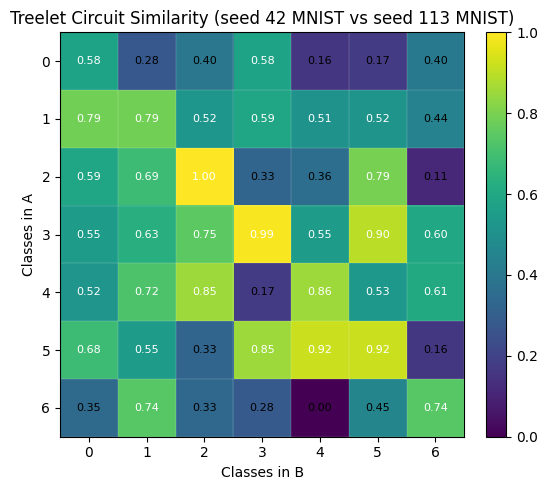

Frobenius norm: 3.6384759981861894


In [80]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mixup05, circuits_photo, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.833439101400157 mean offdiag: 0.6362356131497915


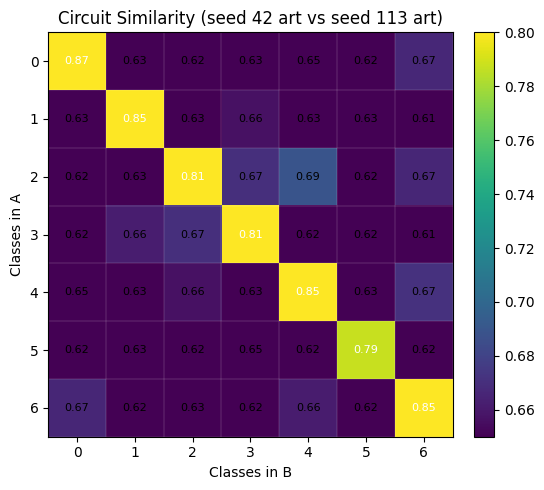

Frobenius norm: 4.149478041773003


In [81]:
%matplotlib inline
vA = build_class_vectors(circuits_mixup03, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_mixup01, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 440.97it/s]
getting canonkeys: 3it [00:00, 12384.76it/s]

 --- treelet kernel matrix of size 2 built in 0.011978864669799805 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 448.78it/s]
getting canonkeys: 3it [00:00, 12658.87it/s]

 --- treelet kernel matrix of size 2 built in 0.011791706085205078 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 462.00it/s]
getting canonkeys: 3it [00:00, 13315.25it/s]

 --- treelet kernel matrix of size 2 built in 0.008415937423706055 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 472.20it/s]
getting canonkeys: 3it [00:00, 13025.79it/s]

 --- treelet kernel matrix of size 2 built in 0.008321762084960938 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 461.29it/s]
getting canonkeys: 3it [00:00, 12098.95it/s]

 --- treelet kernel matrix of size 2 built in 0.010059833526611328 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0

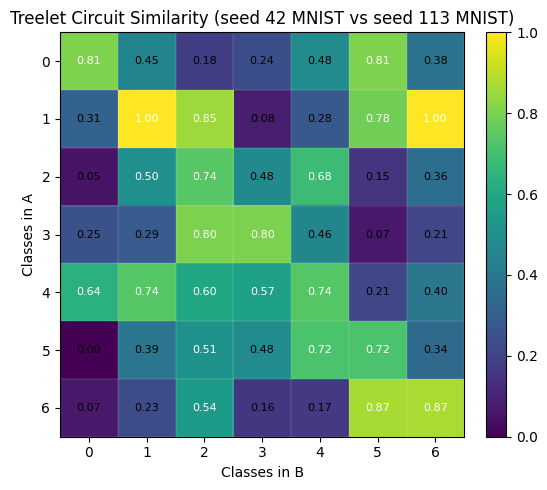

Frobenius norm: 3.2554364275236707


In [82]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mixup03, circuits_mixup01, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7567421269724379 mean offdiag: 0.6311999976641927


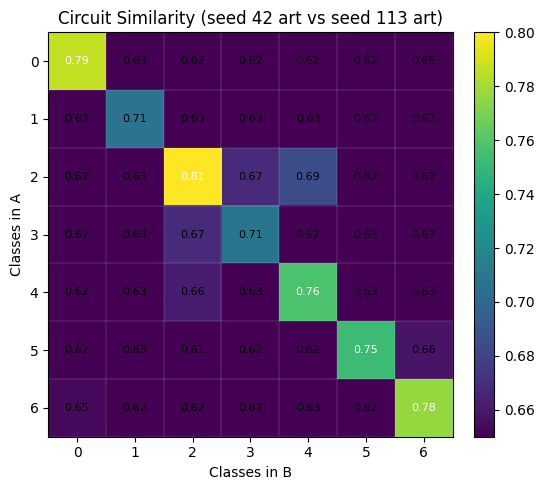

Frobenius norm: 4.143259229471373


In [83]:
%matplotlib inline
vA = build_class_vectors(circuits_mixup03, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_photo, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7659118464022348 mean offdiag: 0.6309960681619091


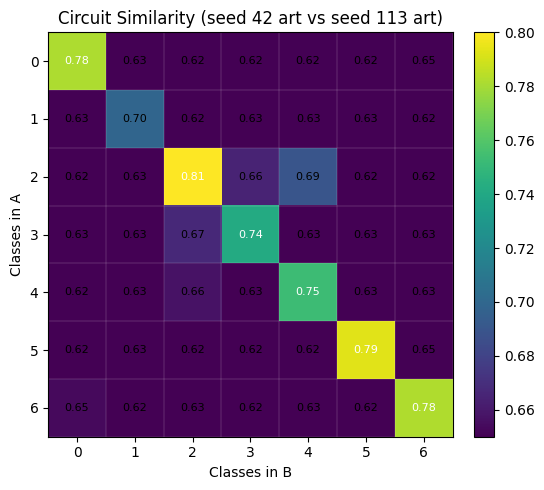

Frobenius norm: 4.138133730974311


In [84]:
%matplotlib inline
vA = build_class_vectors(circuits_mixup01, use_abs_edges=True, include_bias=True)
vB = build_class_vectors(circuits_photo, use_abs_edges=True, include_bias=True)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 478.94it/s]
getting canonkeys: 3it [00:00, 12879.13it/s]

 --- treelet kernel matrix of size 2 built in 0.011049270629882812 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 451.49it/s]
getting canonkeys: 3it [00:00, 12813.56it/s]

 --- treelet kernel matrix of size 2 built in 0.011867046356201172 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 462.72it/s]
getting canonkeys: 3it [00:00, 13386.08it/s]

 --- treelet kernel matrix of size 2 built in 0.011238336563110352 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 463.74it/s]
getting canonkeys: 3it [00:00, 12998.88it/s]

 --- treelet kernel matrix of size 2 built in 0.011306524276733398 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 439.65it/s]
getting canonkeys: 3it [00:00, 12204.57it/s]

 --- treelet kernel matrix of size 2 built in 0.012035608291625977 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0

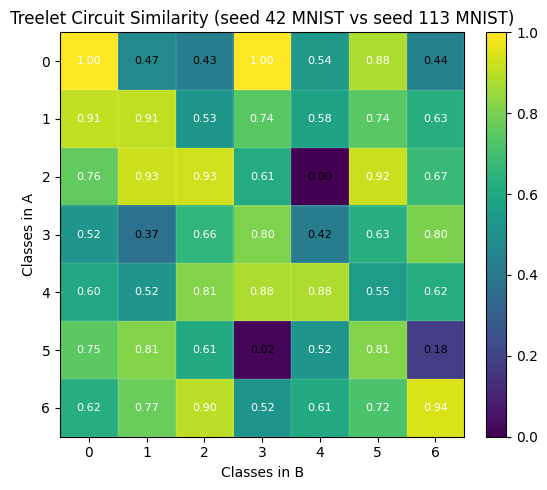

Frobenius norm: 4.298158777979919


In [85]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_mixup01, circuits_photo, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)